# aiswakepy — Run Pipeline

Edit the paths and parameters in **Cell 1** before running.  
Each cell is independent — re-run any stage without restarting the kernel.

In [1]:
# === EDIT THESE PATHS FOR YOUR RUN ===
work_directory   = r"data/compare_JI"   # root folder for this run; change to switch datasets

ais_csv          = f"{work_directory}/ais/DT_JI_ChannelEdited.csv"
coastline_shp    = f"{work_directory}/coastline/JI_shipwake_land_mask.shp"
bathy_file       = f"{work_directory}/bathymetry/JI_bathy.dfsu"
tide_dfs0        = f"{work_directory}/tide/JI_tide_2023.dfs0"
tide_item        = "OSSI: Surface elevation"   # item name inside the .dfs0 file
study_area_shp   = None   # optional polygon shapefile to clip study area, or None

# === OUTPUT FILENAMES (change to save different runs side by side) ===
output_dir           = f"{work_directory}/output/"
wave_height_map_name = "WaveHeightMap.png"
wave_period_map_name = "WavePeriodMap.png"
wave_params_name     = "wave_params.csv"
shore_impact_name    = "shore_impact.csv"
save_stage_csv       = True   # save {ais_stem}_filtered/depth/wave/impact.csv as checkpoints

# === AIS FILTER PARAMETERS ===
traj_gap_s             = 180.0   # split trajectory on gap > this (seconds)
max_velocity_knots     = 36.0    # kinematic check: flag segment if avg speed exceeds this
max_acceleration_ms2   = 20      # acceleration check: replace SOG/COG if implied accel exceeds this
max_draught_to_width   = 1.0     # drop AIS rows where draught > this * width (implausible static data)
interp_interval_s      = 30.0    # Hermite spline interpolation time step (seconds)

# === WAVE CALCULATION PARAMETERS ===
formula        = "kriebel"  # empirical wake model: 'bhowmik', 'blaauw', 'gates', 'kriebel', 'maynord', 'pianc', 'sorensen'
cb_method      = "table"     # block coefficient method: 'L_Le' (Kriebel default), 'B_Le', or 'table'
                            #   L_Le: Cb estimated from waterline length / bow entry length ratio
                            #   B_Le: uses beam instead of length; table: lookup by vessel type
gravity        = 9.78       # local gravitational acceleration (m/s²); Singapore value (vs 9.81 standard)
max_prop_m     = 2000.0     # maximum wake ray propagation distance from vessel track (m);
                            #   rays beyond this are discarded before coastline intersection
wake_cutoff_m  = 0.01       # minimum shore wave height to record (m); events below this are dropped

# === GENERAL WAKE FILTER PARAMETERS (applied regardless of formula) ===
max_sog_knots  = 24.0   # maximum vessel speed (knots)        (fast craft outside calculation range)
max_bl_ratio   = 1.0    # maximum beam / length ratio         (atypical hull form, model not valid)

# === KRIEBEL (2005) APPLICABILITY LIMITS (formula-specific; ignored for other formulas) ===
min_Froude_M   = 0.1    # minimum modified Froude number Fr*  (vessel must be in wave-making regime)
max_Froude_M   = 0.6    # maximum modified Froude number Fr*  (avoids supercritical planing regime)
max_bf         = 0.5    # maximum BF = Beta * (Fr*-0.1)^2     (no data in Kriebel's dataset exceeds 0.4)

# === OSSI COMPARISON PARAMETERS (Cell 9) ===
ossi_xlsx       = f"{work_directory}/OSSI/wake_detection_matches_ss.xlsx"   # OSSI wave gauge events
gauge_lon       = 103.733335   # OSSI gauge longitude (decimal degrees)
gauge_lat       = 1.265771     # OSSI gauge latitude  (decimal degrees)
event_window    = 1.0          # matching window (minutes) for pairing AIS arrivals <-> OSSI events
ossi_cb_method  = "table"       # block coefficient method used in the MATLAB comparison

In [2]:
# === Cell 2: Build config ===
from aiswakepy.config import load_config

config = load_config({
    "ais": {
        "raw_csv": ais_csv,
        "traj_gap_s": traj_gap_s,
        "max_velocity_knots": max_velocity_knots,
        "max_acceleration_ms2": max_acceleration_ms2,
        "max_draught_to_width": max_draught_to_width,
        "interp_interval_s": interp_interval_s,
        "study_area_shp": study_area_shp,
    },
    "vessel": {"cb_method": cb_method},
    "bathymetry": {
        "source": bathy_file,
        "tide_dfs0": tide_dfs0,
        "tide_item": tide_item,
    },
    "coastline": {"shapefile": coastline_shp},
    "wave": {
        "gravity": gravity,
        "min_Froude_M": min_Froude_M,
        "max_Froude_M": max_Froude_M,
        "max_bf": max_bf,
        "max_sog_knots": max_sog_knots,
        "max_bl_ratio": max_bl_ratio,
    },
    "impact": {"max_propagation_m": max_prop_m, "wake_cutoff_m": wake_cutoff_m},
    "output": {
        "directory": output_dir,
        "wave_height_map_name": wave_height_map_name,
        "wave_period_map_name": wave_period_map_name,
        "wave_params_name": wave_params_name,
        "shore_impact_name": shore_impact_name,
        "save_stage_csv": save_stage_csv,
    },
})
print("Config loaded OK")

Config loaded OK


In [3]:
# === Cell 3: Stage 1 — AIS Filter ===
from pathlib import Path
from aiswakepy.stages.filter import filter_ais

df_filtered = filter_ais(
    csv_path=config.ais.raw_csv,
    coastline_shp=config.coastline.shapefile,
    gap_s=config.ais.traj_gap_s,
    max_velocity_knots=config.ais.max_velocity_knots,
    max_acceleration_ms2=config.ais.max_acceleration_ms2,
    max_draught_to_width=config.ais.max_draught_to_width,
    interval_s=config.ais.interp_interval_s,
    study_area_shp=config.ais.study_area_shp,
)
print(f"Filtered and interpolated: {len(df_filtered):,} rows")
if config.output.save_stage_csv:
    _stem = Path(config.ais.raw_csv).stem
    _out = Path(config.output.directory)
    _out.mkdir(parents=True, exist_ok=True)
    df_filtered.to_csv(_out / f"{_stem}_01_filtered.csv", index=False)
    print(f"  saved {_stem}_01_filtered.csv")
df_filtered.head()

Filtered and interpolated: 63,881 rows
  saved DT_JI_ChannelEdited_01_filtered.csv


,mmsi,width,length,draught,obstime,longitude,latitude,sog,cog,typecargo,segment_id
0,209459000,23.0,148.0,9.0,2023-03-05 11:32:03,103.737883,1.262588,12.200000,233.300000,70,1
1,209459000,23.0,148.0,9.0,2023-03-05 11:32:33,103.736480,1.261567,12.678754,234.234216,70,1
2,209459000,23.0,148.0,9.0,2023-03-05 11:33:03,103.735062,1.260532,12.500000,233.200000,70,1
3,209459000,23.0,148.0,9.0,2023-03-05 11:33:33,103.733659,1.259478,12.711188,233.137193,70,1
4,209459000,23.0,148.0,9.0,2023-03-05 11:34:03,103.732243,1.258429,12.616997,233.916914,70,1


In [4]:
# === Cell 4: Stage 2 — Depth + Tide Assignment ===
from aiswakepy.stages.depth import assign_depth

df_depth = assign_depth(
    df=df_filtered,
    bathy_path=config.bathymetry.source,
    tide_dfs0_path=config.bathymetry.tide_dfs0,
    tide_item=config.bathymetry.tide_item,
    underkeel_margin_m=config.bathymetry.underkeel_margin_m,
)
print(f"After depth filter: {len(df_depth)} rows")
if config.output.save_stage_csv:
    df_depth.to_csv(_out / f"{_stem}_02_depth.csv", index=False)
    print(f"  saved {_stem}_02_depth.csv")
df_depth[["WaterDepth", "draught"]].describe()

After depth filter: 61073 rows
  saved DT_JI_ChannelEdited_02_depth.csv


,WaterDepth,draught
count,61073.000000,61073.000000
mean,18.769544,5.457158
std,5.097969,2.357548
min,5.445060,1.000000
25%,13.757883,4.000000
50%,20.009540,5.000000
75%,22.546537,7.000000
max,31.385574,15.000000


In [5]:
# === Cell 5: Stage 3 — Vessel Parameters ===
from aiswakepy.stages.vessel import compute_vessel_params

print(
    f"Vessel parameters  cb_method: {cb_method}\n"
    f"  general filters  SOG <= {max_sog_knots} kn  B/L <= {max_bl_ratio}"
)

df_vessel = compute_vessel_params(
    df=df_depth,
    cb_method=config.vessel.cb_method,
    g=config.wave.gravity,
    max_sog_knots=config.wave.max_sog_knots,
    max_bl_ratio=config.wave.max_bl_ratio,
)
print(f"Vessel events: {len(df_vessel)}")
if config.output.save_stage_csv:
    df_vessel.to_csv(_out / f"{_stem}_03_vessel.csv", index=False)
    print(f"  saved {_stem}_03_vessel.csv")
df_vessel[["SOGms", "Froude_D", "T", "Theta", "Cel", "Tc", "BLratio"]].describe()

Vessel parameters  cb_method: table
  general filters  SOG <= 24.0 kn  B/L <= 1.0


Vessel events: 61042
  saved DT_JI_ChannelEdited_03_vessel.csv


,SOGms,Froude_D,T,Theta,Cel,Tc,BLratio
count,61042.000000,61042.000000,61042.000000,61042.000000,61042.000000,61042.000000,61042.000000
mean,2.603516,0.177525,1.366425,35.233493,2.128641,1.367551,0.228711
std,2.466533,0.168357,1.294531,0.265987,2.022927,1.299634,0.087460
min,0.000000,0.000000,0.000000,21.748602,0.000000,0.000000,0.108844
25%,0.015154,0.001378,0.007953,35.256626,0.012373,0.007949,0.165217
50%,2.869922,0.195254,1.506245,35.262133,2.343355,1.505494,0.177778
75%,4.391336,0.298236,2.304740,35.264169,3.585901,2.303771,0.312500
max,12.346666,0.920082,6.480000,35.264173,11.139983,7.156910,0.814815


In [6]:
# === Cell 6: Stage 4 — Wave Impact ===
from aiswakepy.stages.wave_impact import compute_wave_impact

print(
    f"Wave impact  formula: {formula}\n"
    f"  Kriebel limits  Froude_M = [{min_Froude_M}, {max_Froude_M}]  BF <= {max_bf}"
)

df_wave_impact = compute_wave_impact(
    df_vessel=df_vessel,
    coastline_shp=config.coastline.shapefile,
    formula=formula,
    max_propagation_m=config.impact.max_propagation_m,
    wake_cutoff_m=config.impact.wake_cutoff_m,
    g=config.wave.gravity,
    rho=config.wave.rho_water,
    # Kriebel-specific applicability limits (ignored for other formulas)
    min_Froude_M=config.wave.min_Froude_M,
    max_Froude_M=config.wave.max_Froude_M,
    max_bf=config.wave.max_bf,
)
print(f"Shore impact events: {len(df_wave_impact)}")
if config.output.save_stage_csv:
    df_wave_impact.to_csv(_out / f"{_stem}_04_wave_impact.csv", index=False)
    print(f"  saved {_stem}_04_wave_impact.csv")
df_wave_impact.head()

Wave impact  formula: kriebel
  Kriebel limits  Froude_M = [0.1, 0.6]  BF <= 0.5


Shore impact events: 13156
  saved DT_JI_ChannelEdited_04_wave_impact.csv


,MMSI,ShLongitude,ShLatitude,WavePeriod,DistLoc_km,DateTime,Froude_D,VesselWidth,VesselLength,SOG,Side,WaveHeight
0,209459000,103.728749,1.262354,3.293338,0.586746,2023-03-05 11:32:03,0.400964,23.0,148.0,12.200000,stbd,0.272514
1,209459000,103.726873,1.261479,3.422351,0.617003,2023-03-05 11:32:33,0.382379,23.0,148.0,12.678754,stbd,0.289236
2,209459000,103.724209,1.260235,3.373980,0.697304,2023-03-05 11:33:03,0.370207,23.0,148.0,12.500000,stbd,0.248442
3,209540000,103.725624,1.260896,3.752924,0.706027,2023-03-02 03:22:12,0.437499,22.0,139.0,13.900000,stbd,0.373202
4,209798000,103.727353,1.261703,3.888680,0.650413,2023-03-19 04:42:00,0.464566,32.0,260.0,14.400000,stbd,0.449053


In [7]:
# === Cell 7: Visualisation ===
from pathlib import Path
from aiswakepy.viz.wave_map import plot_wave_height_map, plot_wave_period_map

out = Path(output_dir)
out.mkdir(parents=True, exist_ok=True)

plot_wave_height_map(df_wave_impact, coastline_shp, out / wave_height_map_name, max_points=100_000)
plot_wave_period_map(df_wave_impact, coastline_shp, out / wave_period_map_name, max_points=100_000)
print(f"Maps saved to {out.resolve()}")

Maps saved to C:\Projects\61803960 SCDF Metocean (Sub)\Tools\PROJ-61803960-AISWAKEPY-WUHL\data\compare_JI\output


In [8]:
# === Cell 8: Export final results ===
# Stage CSVs are already saved above.
# This cell saves final outputs using the configured filenames.
from pathlib import Path

out = Path(output_dir)
df_vessel.to_csv(out / wave_params_name, index=False)
df_wave_impact.to_csv(out / shore_impact_name, index=False)
print(f"Results saved to {out.resolve()}")

Results saved to C:\Projects\61803960 SCDF Metocean (Sub)\Tools\PROJ-61803960-AISWAKEPY-WUHL\data\compare_JI\output


## Cell 9 — Compare All Formulae to OSSI Measurements

Runs all 7 empirical formulae against the OSSI wave gauge and compares
predicted vs measured wave heights.  Uses `compute_point_impact` to find
wake arrivals at the gauge, then applies each formula at the computed
lateral distance.

**Requires**: `ossi_xlsx`, `gauge_lon`, `gauge_lat` set in Cell 1.
Uses `df_vessel` from Cell 5 (re-derives block coefficients with `ossi_cb_method`).

In [9]:
# === Cell 9a: OSSI comparison — Step 1 ===
# Prepare vessel data (re-derive Cb with ossi_cb_method if different)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from aiswakepy.stages.wave_impact import compute_point_impact
from aiswakepy.models.kriebel  import compute_kriebel
from aiswakepy.models.pianc    import compute_pianc
from aiswakepy.models.bhowmik  import compute_bhowmik
from aiswakepy.models.gates    import compute_gates
from aiswakepy.models.blaauw   import compute_blaauw
from aiswakepy.models.sorensen import compute_sorensen
from aiswakepy.models.maynord  import compute_maynord
from aiswakepy.vessel.block_coeff import get_vessel_params_df

df_ossi_vessel = df_vessel.copy()
if ossi_cb_method != cb_method:
    df_ossi_vessel = get_vessel_params_df(df_ossi_vessel, method=ossi_cb_method)
    df_ossi_vessel["displacement_m3"] = (
        df_ossi_vessel["width"] * df_ossi_vessel["draught"]
        * df_ossi_vessel["length"] * 0.95 * df_ossi_vessel["block_coeff"]
    )

# Drop zero-draught records (unreliable AIS static data)
df_ossi_vessel = df_ossi_vessel[df_ossi_vessel["draught"] > 0].reset_index(drop=True)
print(f"Vessel records for OSSI comparison: {len(df_ossi_vessel)}")

Vessel records for OSSI comparison: 61042


In [10]:
# === Cell 9b: OSSI comparison — Step 2 ===
# Find wake arrivals at the OSSI gauge
print(f"Finding wake arrivals at gauge ({gauge_lon}, {gauge_lat})...")
events = compute_point_impact(
    df_ossi_vessel, gauge_lon, gauge_lat,
    g=gravity, max_prop_m=max_prop_m,
)
print(f"  {len(events)} wake-arrival events")
print(f"  Unique vessels: {events['MMSI'].nunique()}")

if events.empty:
    raise RuntimeError("No wake events reached the gauge — check gauge coordinates and AIS data overlap.")

Finding wake arrivals at gauge (103.733335, 1.265771)...
  10082 wake-arrival events
  Unique vessels: 642


In [11]:
# === Cell 9c: OSSI comparison — Step 3 ===
# Compute wave height with all 7 formulae
_formulae = {
    "Kriebel":  (compute_kriebel,  {"min_Froude_M": min_Froude_M, "max_Froude_M": max_Froude_M, "max_bf": max_bf}),
    "PIANC":    (compute_pianc,    {}),
    "Sorensen": (compute_sorensen, {}),
    "Maynord":  (compute_maynord,  {}),
    "Bhowmik":  (compute_bhowmik,  {}),
    "Gates":    (compute_gates,    {}),
    "Blaauw":   (compute_blaauw,   {}),
}

for label, (fn, kw) in _formulae.items():
    col = f"H_{label}"
    events[col] = fn(events, g=gravity, **kw).values
    n_valid = events[col].notna().sum() & (events[col] > 0).sum()
    print(f"  {label}: {n_valid} valid predictions")

  Kriebel: 2780 valid predictions
  PIANC: 9981 valid predictions
  Sorensen: 3194 valid predictions
  Maynord: 3540 valid predictions
  Bhowmik: 10082 valid predictions
  Gates: 9851 valid predictions
  Blaauw: 9981 valid predictions


c:\Projects\61803960 SCDF Metocean (Sub)\Tools\PROJ-61803960-AISWAKEPY-WUHL\aiswakepy\models\sorensen.py:87: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(log_alpha)


In [12]:
# === Cell 9d: OSSI comparison — Step 4 ===
# Load OSSI measurements
from aiswakepy.comparison import load_ossi

print(f"Loading OSSI measurements from {ossi_xlsx}...")
ossi = load_ossi(ossi_xlsx)
print(f"  {len(ossi)} OSSI wave events loaded")

Loading OSSI measurements from data/compare_JI/OSSI/wake_detection_matches_ss.xlsx...
  201 OSSI wave events loaded


In [13]:
# === Cell 9e: OSSI comparison — Step 5 ===
# Match wake arrivals <-> OSSI events (nearest within +/-event_window min).
# If the OSSI xlsx carries an optional MMSI column (i.e. events were derived
# from AIS), matching is restricted to the same MMSI so one OSSI event cannot
# be claimed by multiple vessels.
# Deduplication: each OSSI event is then assigned to at most one AIS arrival
# (the nearest), so n_matched <= len(ossi).
from aiswakepy.comparison import match_event_indices
import pandas as _pd

_idx, _dt = match_event_indices(
    events["ArrivalTime"], ossi, event_window,
    ais_mmsi=events["MMSI"] if "MMSI" in ossi.columns else None,
)

# Deduplicate: for each OSSI event keep only the nearest AIS arrival
_matched = _pd.DataFrame({"ais_i": range(len(events)), "ossi_idx": _idx, "dt": _dt})
_matched = _matched[_matched["ossi_idx"] >= 0]
_dropped_rows = []
if not _matched.empty:
    _keep_idx = _matched.groupby("ossi_idx")["dt"].idxmin()
    _keep_set  = set(_matched.loc[_keep_idx, "ais_i"].to_numpy())
    _drop_set  = set(_matched["ais_i"].to_numpy()) - _keep_set

    # Build diagnostic table for dropped duplicates
    for _, row in _matched[_matched["ais_i"].isin(_drop_set)].iterrows():
        ais_i    = int(row["ais_i"])
        ossi_i   = int(row["ossi_idx"])
        winner_i = int(_matched.loc[_matched["ossi_idx"] == ossi_i].loc[
            _matched.loc[_matched["ossi_idx"] == ossi_i, "dt"].idxmin(), "ais_i"])
        _dropped_rows.append({
            "MMSI":          events.iloc[ais_i]["MMSI"],
            "ArrivalTime":   events.iloc[ais_i]["ArrivalTime"],
            "dt_min":        row["dt"],
            "OSSI_time":     ossi.iloc[ossi_i]["time"],
            "winner_ArrivalTime": events.iloc[winner_i]["ArrivalTime"],
            "winner_dt_min": float(_matched.loc[_matched["ais_i"] == winner_i, "dt"].iloc[0]),
        })

    _keep_arr = _matched.loc[_keep_idx, "ais_i"].to_numpy()
    _new_idx = np.full(len(events), -1, dtype=np.int64)
    _new_dt  = np.full(len(events), np.nan)
    _new_idx[_keep_arr] = _idx[_keep_arr]
    _new_dt[_keep_arr]  = _dt[_keep_arr]
    _idx, _dt = _new_idx, _new_dt

_ok = _idx >= 0
_ossi_h = ossi["Hmax"].to_numpy(dtype=float)
_ossi_t = ossi["T"].to_numpy(dtype=float)

events["Hmax_measured"] = np.where(_ok, _ossi_h[np.maximum(_idx, 0)], np.nan)
events["T_measured"]    = np.where(_ok, _ossi_t[np.maximum(_idx, 0)], np.nan)
events["match_dt_min"]  = _dt

n_matched = events["Hmax_measured"].notna().sum()
_mmsi_note = "  (MMSI-constrained)" if "MMSI" in ossi.columns else ""
print(f"  {n_matched} matched wake<->OSSI pairs (+/-{event_window} min window){_mmsi_note}")
print(f"  (deduplicated: each of {len(ossi)} OSSI events matched to at most one AIS arrival)")

if _dropped_rows:
    _drop_df = _pd.DataFrame(_dropped_rows)
    print(f"\n  Dropped {len(_drop_df)} duplicate AIS arrival(s) during deduplication:")
    print("  (each competed for the same OSSI event but was farther in time than the winner)\n")
    for _, r in _drop_df.iterrows():
        print(f"    MMSI {int(r['MMSI'])}  ArrivalTime={r['ArrivalTime']}  dt={r['dt_min']:.3f} min")
        print(f"      -> competed for OSSI event at {r['OSSI_time']}")
        print(f"      -> winner: ArrivalTime={r['winner_ArrivalTime']}  dt={r['winner_dt_min']:.3f} min")
else:
    print("  No duplicates found — all OSSI events had a unique nearest AIS arrival.")


  201 matched wake<->OSSI pairs (+/-1.0 min window)  (MMSI-constrained)
  (deduplicated: each of 201 OSSI events matched to at most one AIS arrival)

  Dropped 4 duplicate AIS arrival(s) during deduplication:
  (each competed for the same OSSI event but was farther in time than the winner)

    MMSI 477985800  ArrivalTime=2023-03-11 21:48:06.403168  dt=0.097 min
      -> competed for OSSI event at 2023-03-11 21:48:00.600000
      -> winner: ArrivalTime=2023-03-11 21:48:05.918193033  dt=0.089 min
    MMSI 563034300  ArrivalTime=2023-03-13 07:57:21.222968265  dt=0.817 min
      -> competed for OSSI event at 2023-03-13 07:56:32.200000
      -> winner: ArrivalTime=2023-03-13 07:55:45.111582797  dt=0.785 min
    MMSI 563069230  ArrivalTime=2023-03-06 22:33:31.881955228  dt=0.741 min
      -> competed for OSSI event at 2023-03-06 22:32:47.400000
      -> winner: ArrivalTime=2023-03-06 22:32:58.510656768  dt=0.185 min
    MMSI 564654000  ArrivalTime=2023-03-01 22:08:43.074322509  dt=0.549 min

In [14]:
# === Cell 9f: OSSI comparison — Step 6 ===
# Setup colours and column map
from aiswakepy.comparison import COLOURS

pred_cols = {label: f"H_{label}" for label in _formulae}
print(f"Prediction columns: {list(pred_cols.keys())}")

Prediction columns: ['Kriebel', 'PIANC', 'Sorensen', 'Maynord', 'Bhowmik', 'Gates', 'Blaauw']


  saved timeseries_all.png


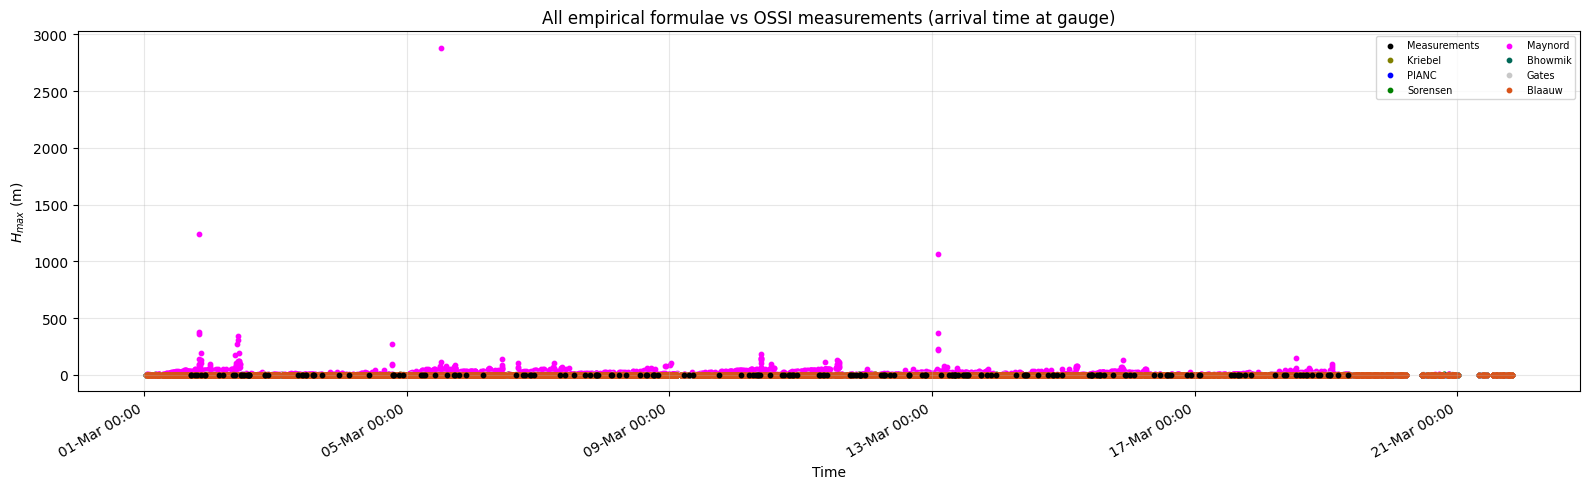

In [15]:
# === Cell 9g: OSSI comparison — Step 7 ===
# Time series plot — all predictions + measurements
from pathlib import Path
from aiswakepy.comparison import timeseries_plot

out = Path(output_dir) / "comparison"
out.mkdir(parents=True, exist_ok=True)

fig = timeseries_plot(
    events, ossi, pred_cols,
    title="All empirical formulae vs OSSI measurements (arrival time at gauge)",
    out_path=out / "timeseries_all.png",
)
plt.show()

  saved timeseries_zoom_lines.png


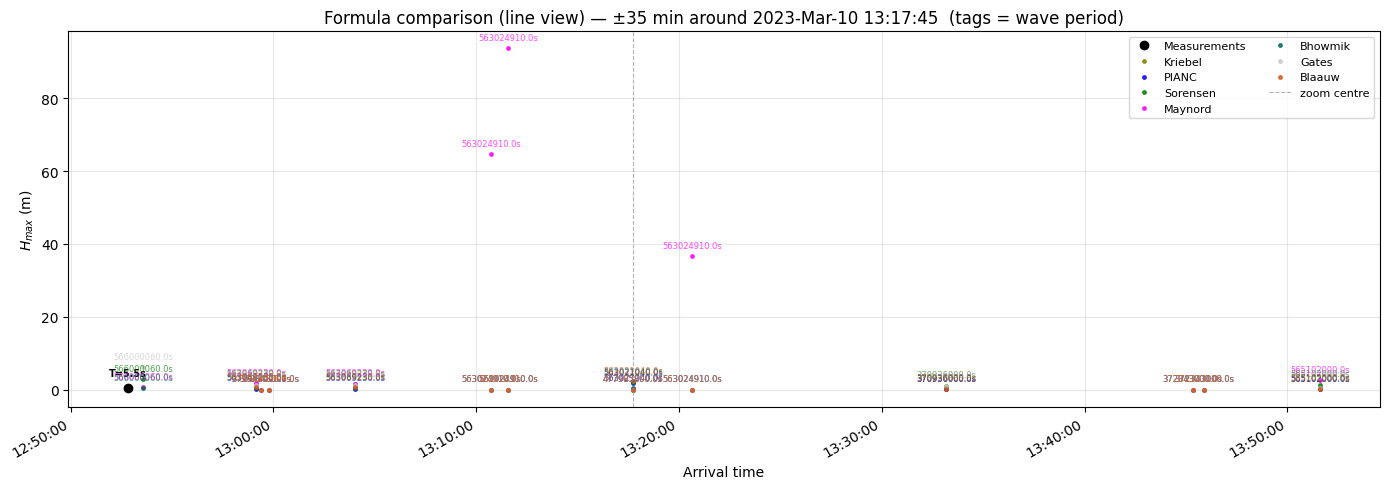

In [16]:
# === Cell 9g-zoom: Time-series zoom with line plot — see formula trends in narrow window ===
# Adjust these variables for the window of interest.

zoom_centre_g  = pd.Timestamp("2023-03-10 13:17:45")   # centre of the zoom window
zoom_half_min_g = 35                                    # half-window either side (minutes)

# ── filter data ──────────────────────────────────────────────────────────────
t_lo_g = zoom_centre_g - pd.Timedelta(minutes=zoom_half_min_g)
t_hi_g = zoom_centre_g + pd.Timedelta(minutes=zoom_half_min_g)

ev_zoom_g   = events[(events["ArrivalTime"] >= t_lo_g) & (events["ArrivalTime"] <= t_hi_g)].sort_values("ArrivalTime")
ossi_zoom_g = ossi[(ossi["time"] >= t_lo_g) & (ossi["time"] <= t_hi_g)].sort_values("time")

# ── plot (line style with markers) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# OSSI measured (black dots + line) — tag shows measured period T (s)
if not ossi_zoom_g.empty:
    ax.plot(ossi_zoom_g["time"], ossi_zoom_g["Hmax"],
            c=COLOURS["OSSI"], marker="o", ms=6, ls="None", label="Measurements", zorder=5)
    for _, row in ossi_zoom_g.iterrows():
        T_val = row.get("T", float("nan"))
        tag = f"T={T_val:.1f}s" if pd.notna(T_val) else "T=–"
        ax.annotate(tag,
                    xy=(row["time"], row["Hmax"]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=7, color=COLOURS["OSSI"], fontweight="bold")

# Each formula as a line with markers — tag shows AIS-computed WavePeriod (s)
for label, col in pred_cols.items():
    if col not in ev_zoom_g.columns:
        continue
    valid = ev_zoom_g[ev_zoom_g[col].notna() & (ev_zoom_g[col] > 0)].sort_values("ArrivalTime")
    if not valid.empty:
        ax.plot(valid["ArrivalTime"], valid[col],
                c=COLOURS.get(label), marker=".", ms=5, ls="None", label=label, alpha=0.8)
        for _, row in valid.iterrows():
            T_val = row.get("MMSI", float("nan"))
            tag = f"{T_val:.1f}s" if pd.notna(T_val) else "–"
            ax.annotate(tag,
                        xy=(row["ArrivalTime"], row[col]),
                        xytext=(0, 6), textcoords="offset points",
                        ha="center", fontsize=6, color=COLOURS.get(label), alpha=0.7)

ax.axvline(zoom_centre_g, color="gray", lw=0.8, ls="--", alpha=0.6, label="zoom centre")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.set_ylabel("$H_{max}$ (m)")
ax.set_xlabel("Arrival time")
ax.set_title(
    f"Formula comparison (line view) — ±{zoom_half_min_g:.0f} min around "
    f"{zoom_centre_g.strftime('%Y-%b-%d %H:%M:%S')}  (tags = wave period)"
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(out / "timeseries_zoom_lines.png", dpi=150)
print(f"  saved timeseries_zoom_lines.png")
plt.show()

  saved qq_per_formula.png


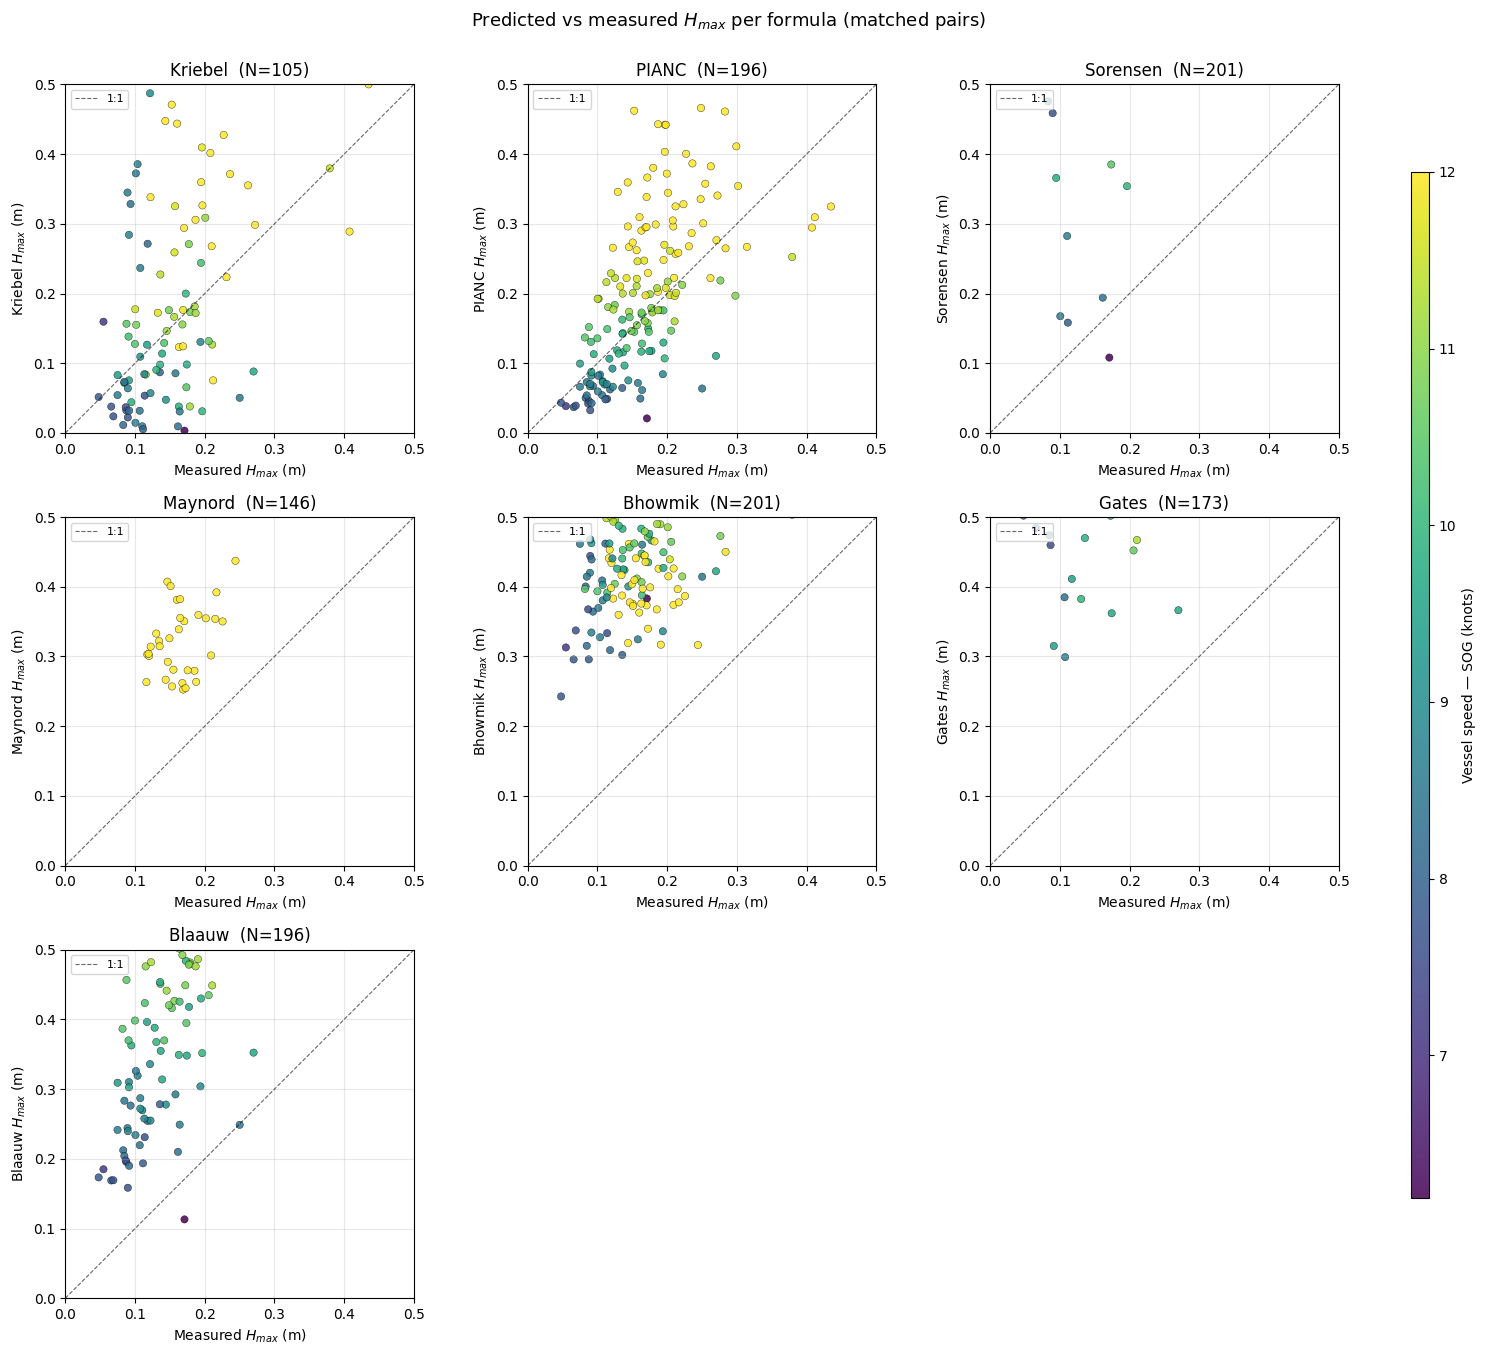

In [17]:
# === Cell 9h: OSSI comparison — Step 8 ===
# QQ plot per formula (matched events only) — predicted vs measured on matched pairs
# Point colour encodes vessel speed (SOG, knots); shared palette across subplots.
n_f = len(pred_cols)
ncols = 3
nrows = int(np.ceil(n_f / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
sog_limit = 12.0
# Shared SOG colour scale across all subplots
_matched_all = events[events["Hmax_measured"].notna()]
sog_vmin = float(_matched_all["SOG"].min())
#sog_vmax = float(_matched_all["SOG"].max())
sog_vmax = float(sog_limit)
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=sog_vmin, vmax=sog_vmax)

scatter_handle = None
for i, (label, col) in enumerate(pred_cols.items()):
    ax = axes[i // ncols][i % ncols]
    valid = events[[col, "Hmax_measured", "SOG"]].dropna()
    valid = valid[(valid[col] > 0) & (valid["Hmax_measured"] > 0)]

    if valid.empty:
        ax.set_title(f"{label} (no matched data)")
        ax.axis("off")
        continue

    meas = valid["Hmax_measured"].to_numpy()
    pred = valid[col].to_numpy()
    sog  = valid["SOG"].to_numpy()

    sc = ax.scatter(meas, pred, c=sog, cmap=cmap, norm=norm,
                    s=28, alpha=0.85, edgecolor="k", lw=0.3)
    scatter_handle = scatter_handle or sc

    lim = max(meas.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.6, label="1:1")
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.5)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Measured $H_{max}$ (m)")
    ax.set_ylabel(f"{label} $H_{{max}}$ (m)")
    ax.set_title(f"{label}  (N={len(valid)})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

# Hide unused axes
for j in range(n_f, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle("Predicted vs measured $H_{max}$ per formula (matched pairs)", fontsize=13, y=1.00)
fig.tight_layout(rect=[0, 0, 0.94, 1.0])

if scatter_handle is not None:
    cax = fig.add_axes([0.955, 0.12, 0.012, 0.76])
    cbar = fig.colorbar(scatter_handle, cax=cax)
    cbar.set_label("Vessel speed — SOG (knots)")

fig.savefig(out / "qq_per_formula.png", dpi=150, bbox_inches="tight")
print(f"  saved qq_per_formula.png")
plt.show()

  saved error_vs_properties.png


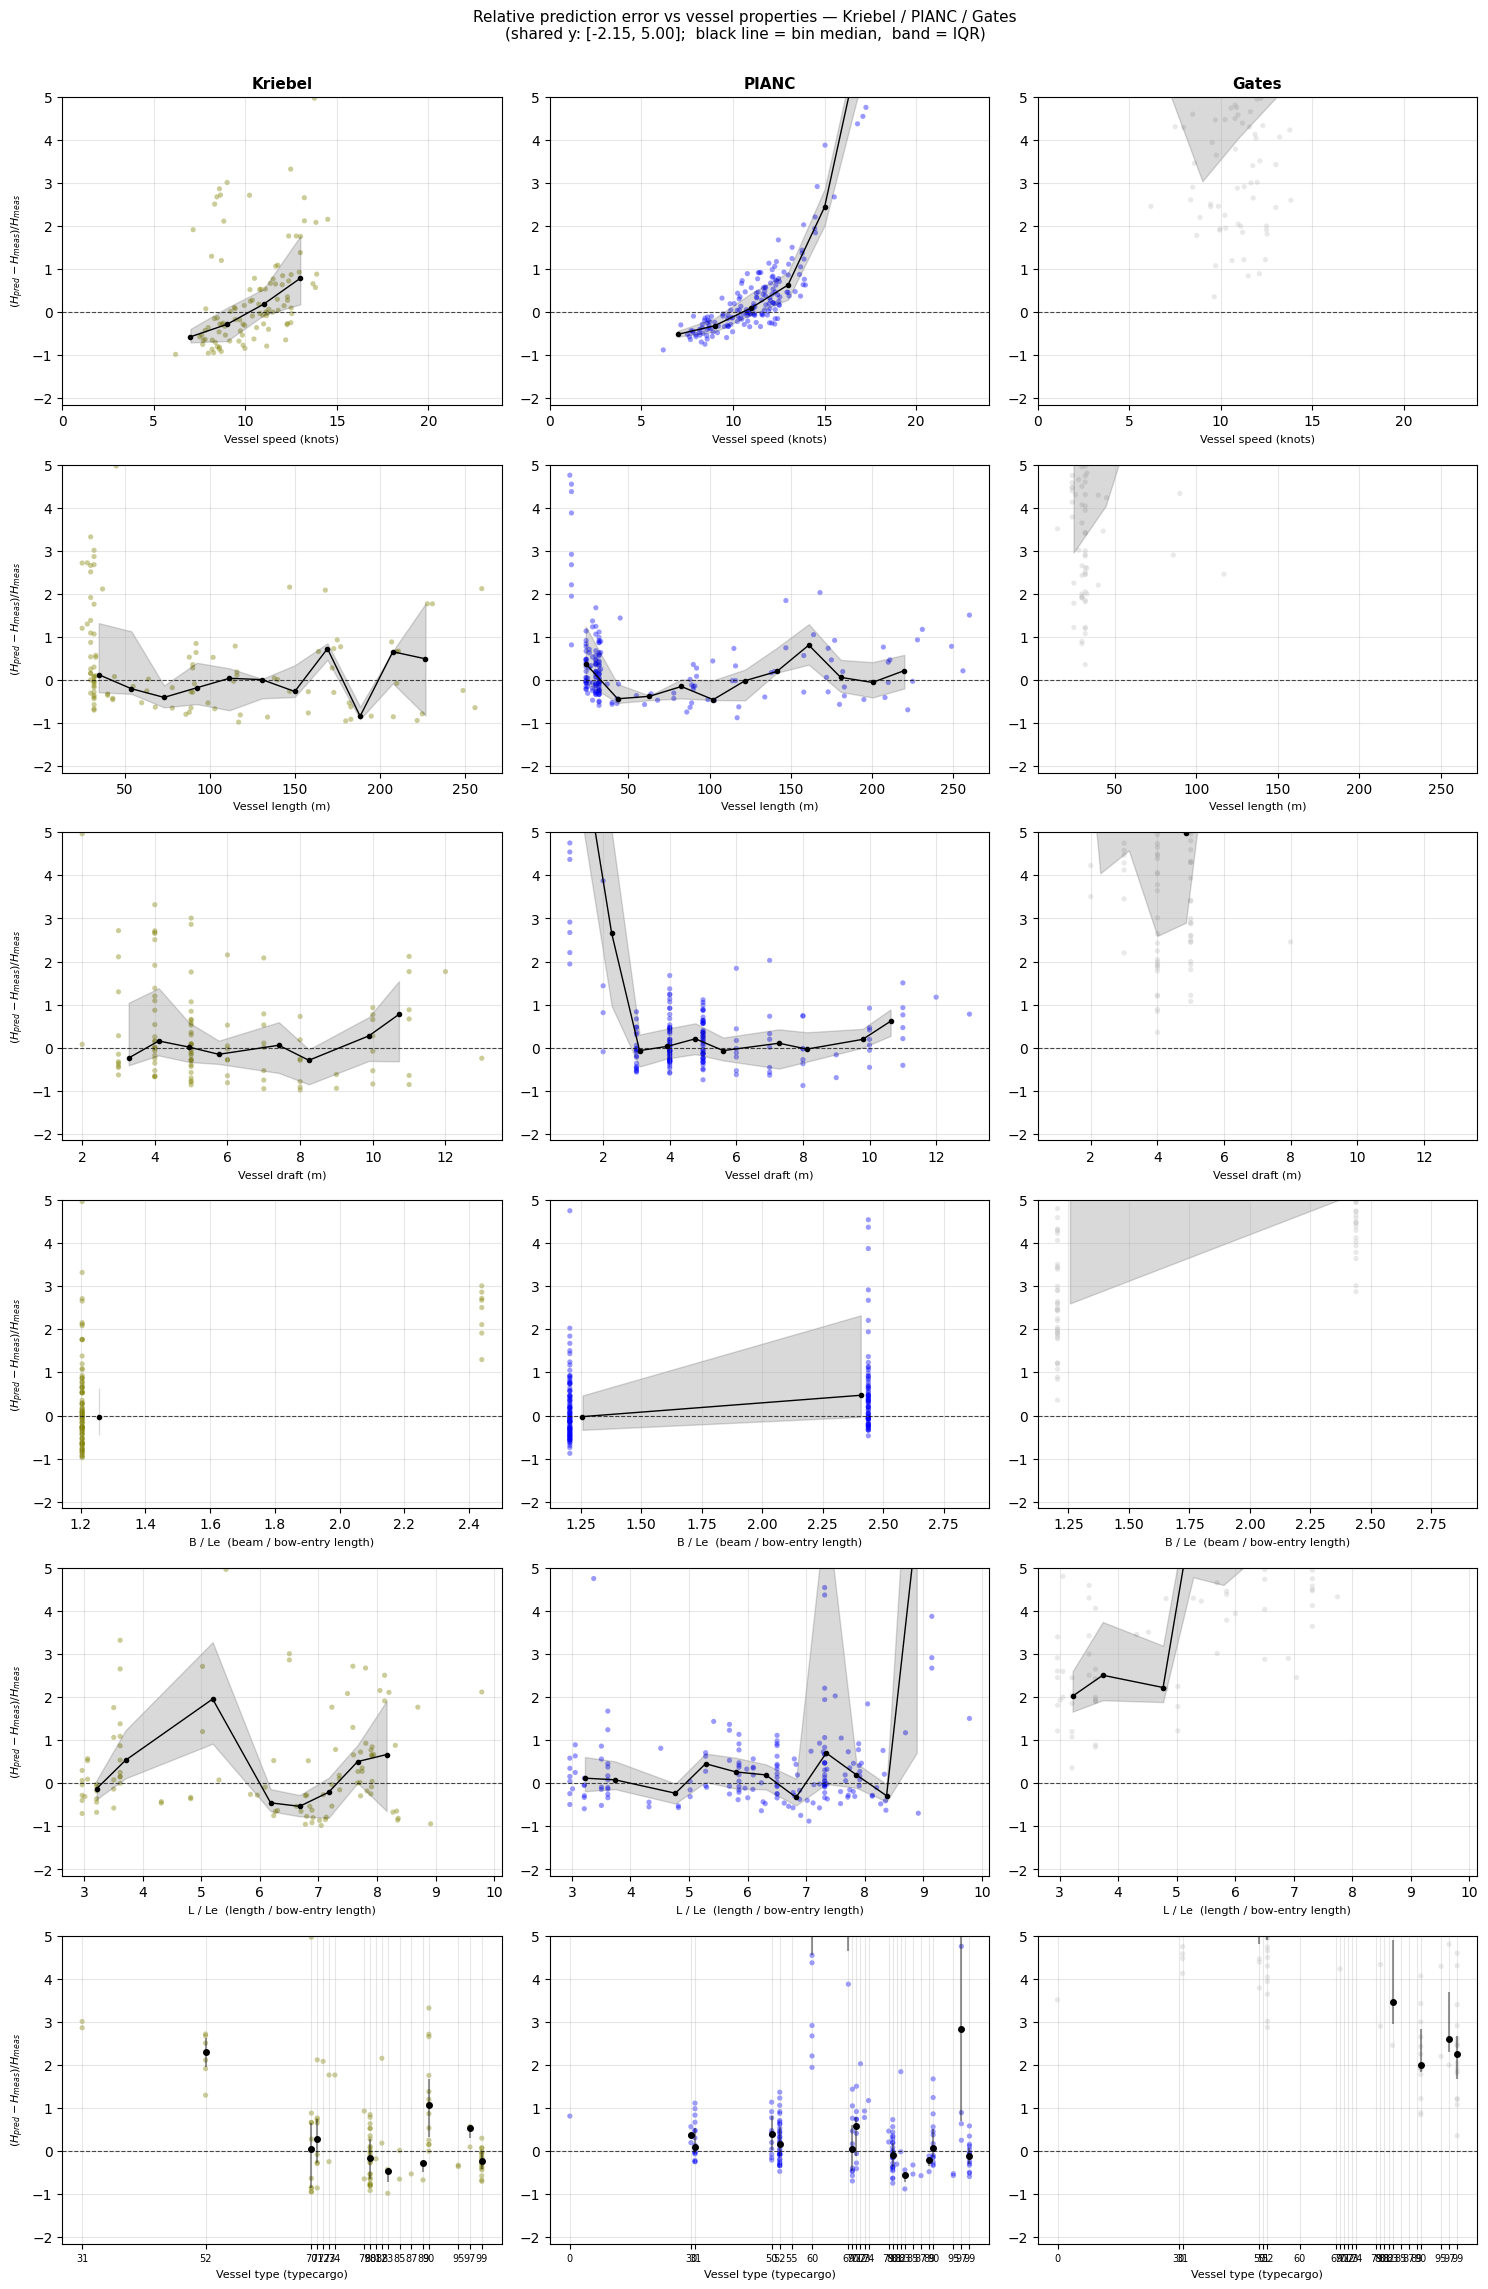

In [18]:
# === Cell 9h-speed: Relative error vs vessel properties — Kriebel, PIANC, Gates ===
# Layout: 3 cols = method, 6 rows = x-variable
# y-axis: relative error = (H_pred - H_meas) / H_meas  (shared limits, hard cap ±5)
_methods = ["Kriebel", "PIANC", "Gates"]

# ── derive extra columns ──────────────────────────────────────────────────────
_ev = events.copy()
_ev["B_Le"]     = _ev["width"]  / _ev["bow_entry_m"]
_ev["L_Le"]     = _ev["length"] / _ev["bow_entry_m"]
_tc_map         = df_ossi_vessel.groupby("mmsi")["typecargo"].first()
_ev["typecargo"]= _ev["MMSI"].map(_tc_map)

# ── shared y-limits from selected methods only ────────────────────────────────
_all_rel = []
for _lbl in _methods:
    _col = f"H_{_lbl}"
    _v = _ev[[_col, "Hmax_measured"]].dropna()
    _v = _v[(_v[_col] > 0) & (_v["Hmax_measured"] > 0)]
    if not _v.empty:
        _all_rel.append((_v[_col].to_numpy() - _v["Hmax_measured"].to_numpy()) / _v["Hmax_measured"].to_numpy())
if _all_rel:
    _cat = np.concatenate(_all_rel)
    _p2, _p98 = np.percentile(_cat, [2, 98])
    _m = (_p98 - _p2) * 0.08
    _y_lo, _y_hi = _p2 - _m, min(_p98 + _m, 5)
else:
    _y_lo, _y_hi = -1, 5

# ── axis spec: (row label, column in _ev, xlim or None, is_categorical) ──────
_row_specs = [
    ("Vessel speed (knots)",    "SOG",       (0, 24), False),
    ("Vessel length (m)",       "length",    None,    False),
    ("Vessel draft (m)",        "draught",   None,    False),
    ("B / Le  (beam / bow-entry length)", "B_Le", None, False),
    ("L / Le  (length / bow-entry length)", "L_Le", None, False),
    ("Vessel type (typecargo)", "typecargo", None,    True),
]

nrows = len(_row_specs)
ncols = len(_methods)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 3.8 * nrows), squeeze=False)

for col_i, method in enumerate(_methods):
    col = f"H_{method}"
    _xcols = [rs[1] for rs in _row_specs]
    _need  = _xcols + [col, "Hmax_measured"]
    vdf = _ev[[c for c in _need if c in _ev.columns]].dropna(subset=[col, "Hmax_measured"])
    vdf = vdf[(vdf[col] > 0) & (vdf["Hmax_measured"] > 0)].copy()
    vdf["_rel"] = (vdf[col].to_numpy() - vdf["Hmax_measured"].to_numpy()) / vdf["Hmax_measured"].to_numpy()

    for row_i, (xlabel, xcol, xlim, is_cat) in enumerate(_row_specs):
        ax = axes[row_i][col_i]

        if xcol not in vdf.columns:
            ax.text(0.5, 0.5, f"{xcol}\nnot available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9)
            ax.axis("off")
            continue

        sub = vdf[[xcol, "_rel"]].dropna()
        xd  = sub[xcol].to_numpy()
        yd  = sub["_rel"].to_numpy()

        ax.scatter(xd, yd, s=14, alpha=0.40, edgecolor="none",
                   color=COLOURS.get(method, "steelblue"))
        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.7)

        if is_cat:
            cats = np.array(sorted(sub[xcol].unique()))
            bcs, meds, q25s, q75s = [], [], [], []
            for cat in cats:
                e = yd[xd == cat]
                if len(e) >= 3:
                    bcs.append(cat); meds.append(np.median(e))
                    q25s.append(np.percentile(e, 25)); q75s.append(np.percentile(e, 75))
            if bcs:
                bcs = np.array(bcs)
                ax.plot(bcs, meds, "ko", ms=4, zorder=3)
                ax.vlines(bcs, q25s, q75s, color="k", lw=1.5, alpha=0.4)
            ax.set_xticks(cats.astype(int))
            ax.tick_params(axis="x", labelsize=7)
        else:
            x_lo = xlim[0] if xlim else float(np.nanpercentile(xd, 1))
            x_hi = xlim[1] if xlim else float(np.nanpercentile(xd, 99))
            bins = np.linspace(x_lo, x_hi, 13)
            bcs  = 0.5 * (bins[:-1] + bins[1:])
            meds, q25s, q75s = [], [], []
            for lo, hi in zip(bins[:-1], bins[1:]):
                e = yd[(xd >= lo) & (xd < hi)]
                if len(e) >= 3:
                    meds.append(np.median(e)); q25s.append(np.percentile(e, 25)); q75s.append(np.percentile(e, 75))
                else:
                    meds.append(np.nan); q25s.append(np.nan); q75s.append(np.nan)
            meds, q25s, q75s = [np.array(x) for x in (meds, q25s, q75s)]
            ok = ~np.isnan(meds)
            if ok.any():
                ax.plot(bcs[ok], meds[ok], "k-o", ms=3, lw=1.0)
                ax.fill_between(bcs[ok], q25s[ok], q75s[ok], alpha=0.15, color="k")
            if xlim:
                ax.set_xlim(xlim)

        ax.set_ylim(_y_lo, _y_hi)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel("$(H_{pred}-H_{meas})/H_{meas}$" if col_i == 0 else "", fontsize=8)
        ax.grid(True, alpha=0.3)
        if row_i == 0:
            ax.set_title(method, fontsize=11, fontweight="bold")

fig.suptitle(
    f"Relative prediction error vs vessel properties — Kriebel / PIANC / Gates\n"
    f"(shared y: [{_y_lo:.2f}, {_y_hi:.2f}];  black line = bin median,  band = IQR)",
    fontsize=11, y=1.002,
)
fig.tight_layout()
fig.savefig(out / "error_vs_properties.png", dpi=150, bbox_inches="tight")
print("  saved error_vs_properties.png")
plt.show()

[[8.6950e-01 2.2800e+02 3.8000e+01 1.1000e+01]
 [4.7000e-01 1.9500e+02 3.3000e+01 1.0000e+01]
 [6.3450e-01 2.0700e+02 3.0000e+01 1.1000e+01]
 [7.5200e-01 1.7200e+02 2.7000e+01 1.0000e+01]
 [6.5800e-01 1.3400e+02 2.3000e+01 5.0000e+00]
 [6.3450e-01 1.1400e+02 1.9000e+01 6.0000e+00]
 [4.2300e-01 2.2500e+02 3.8000e+01 8.0000e+00]
 [8.4600e-01 2.6000e+02 3.2000e+01 1.1000e+01]
 [6.8150e-01 1.6800e+02 2.7000e+01 7.0000e+00]
 [6.1100e-01 9.0000e+01 1.4000e+01 5.0000e+00]
 [6.3450e-01 1.0300e+02 1.5000e+01 4.0000e+00]
 [6.1100e-01 1.4700e+02 2.2000e+01 6.0000e+00]
 [8.4600e-01 2.3100e+02 3.2000e+01 1.2000e+01]
 [6.3450e-01 1.1700e+02 2.0000e+01 8.0000e+00]
 [1.1280e+00 3.7000e+01 1.1000e+01 3.0000e+00]
 [6.1100e-01 7.8000e+01 1.2000e+01 4.0000e+00]
 [6.1100e-01 1.4000e+02 2.2000e+01 7.0000e+00]
 [5.1700e-01 1.8300e+02 3.2000e+01 8.0000e+00]
 [3.7600e-01 2.5600e+02 3.7000e+01 1.1000e+01]
 [5.1700e-01 1.8200e+02 3.2000e+01 1.0000e+01]
 [6.3450e-01 1.0200e+02 1.8000e+01 6.0000e+00]
 [1.1280e+00 

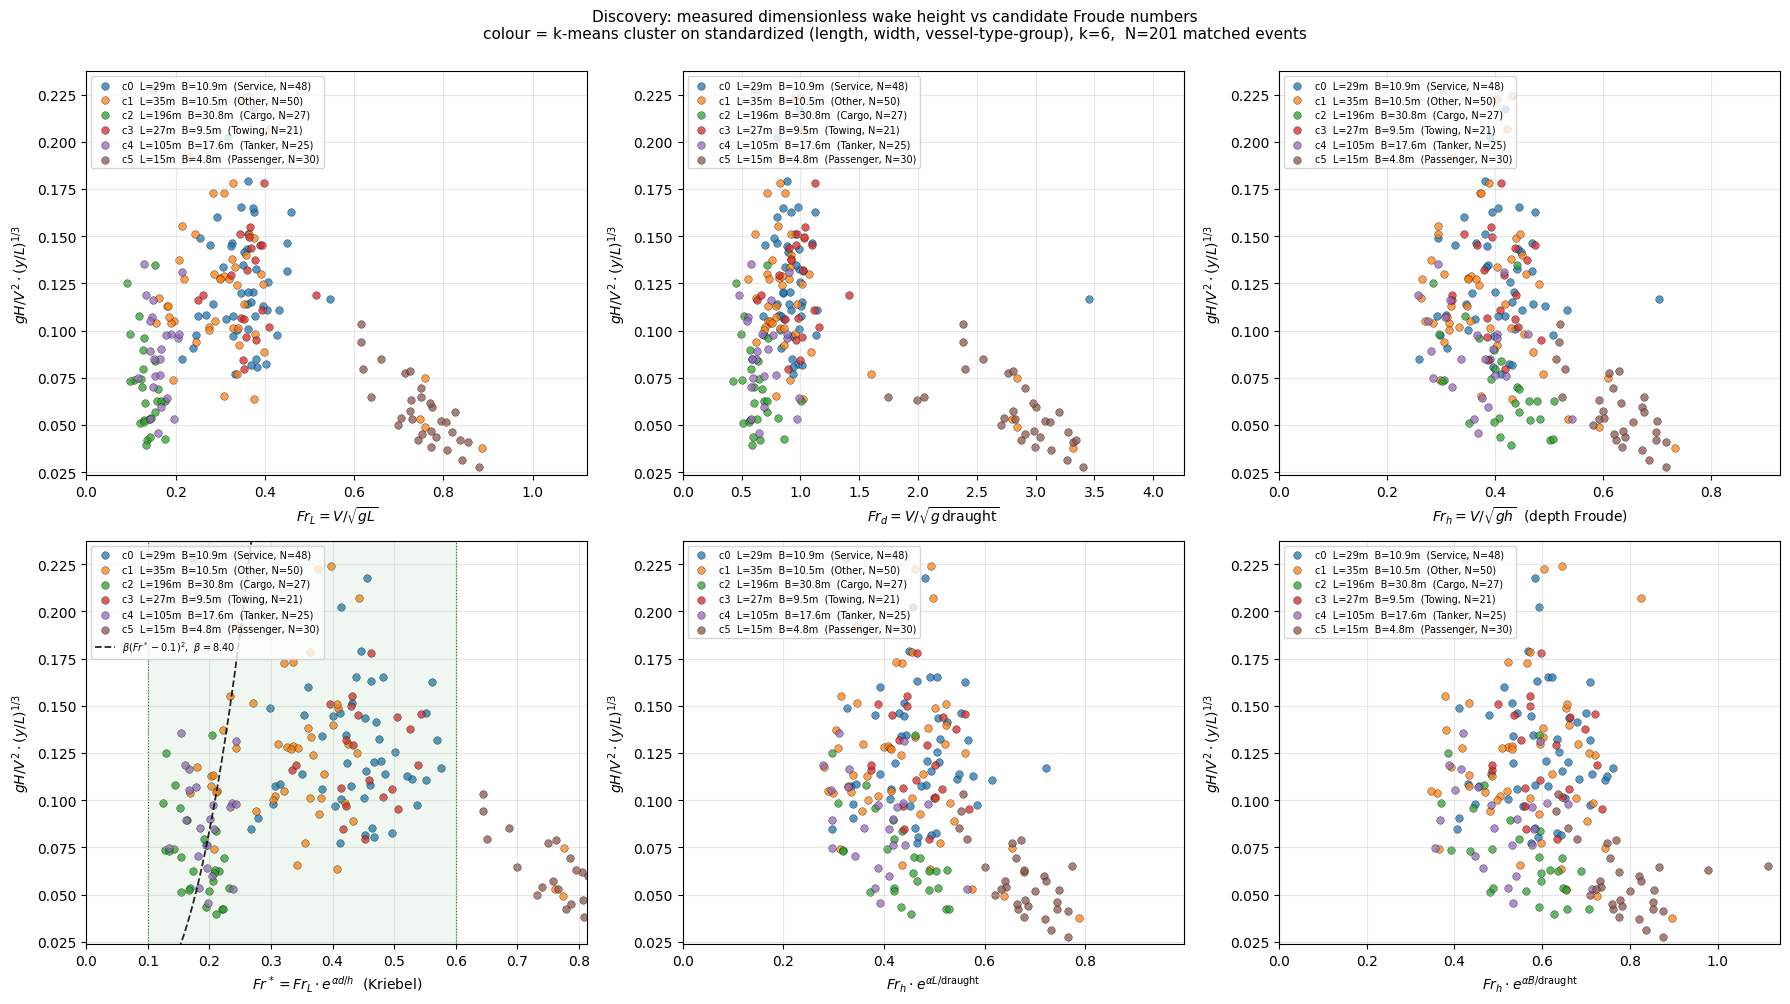

In [19]:
# === Cell 9h-kriebel: Discovery — dimensionless wake vs candidate Froude numbers ===
# Goal: discover which Froude number best collapses the measured dimensionless
#       wake height  gH/V² · (y/L)^(1/3),  and whether vessel cluster matters.
#
# x-axis (one panel each):
#   1. Fr_L  = V / √(gL)                     length Froude
#   2. Fr_d  = V / √(g · draught)            draught Froude
#   3. Fr_h  = V / √(g · h)                  depth Froude (= Froude_D)
#   4. Fr*   = Fr_L · exp(α · d / h)         Kriebel modified Froude  (α = 2.35·(1−Cb))
#   5. Fr_h · exp(α · L / draught)           depth Froude modified by L/d
#   6. Fr_h · exp(α · B / draught)           depth Froude modified by B/d
#
# colour: k-means cluster on standardized (length, width, vessel-type-group)
# y-axis: gH/V² · (y/L)^(1/3)   — measured matched events only

from scipy.cluster.vq import kmeans2

n_clusters = 6   # tune freely

# ── AIS typecargo (0–99) → coarse vessel-type group + ordinal code ──────────
def _vessel_type_group(t):
    """Return (label, ordinal_code).  Ordinal preserves rough similarity."""
    if t is None or pd.isna(t):
        return ("Unknown/Reserved", 0)
    t = int(t)
    if t == 0 or 1 <= t <= 19 or t in (38, 39):
        return ("Unknown/Reserved", 0)
    if 20 <= t <= 29: return ("WIG",             1)
    if t == 30:       return ("Fishing",         2)
    if 31 <= t <= 32: return ("Towing",          3)
    if t in (33, 34): return ("Dredging/Diving", 4)
    if t == 35:       return ("Military",        5)
    if t == 36:       return ("Sailing",         6)
    if t == 37:       return ("Pleasure",        7)
    if 40 <= t <= 49: return ("HSC",             8)
    if 50 <= t <= 59: return ("Service",         9)
    if 60 <= t <= 69: return ("Passenger",      10)
    if 70 <= t <= 79: return ("Cargo",          11)
    if 80 <= t <= 89: return ("Tanker",         12)
    if 90 <= t <= 99: return ("Other",          13)
    return ("Unknown/Reserved", 0)

# ── matched events with complete Kriebel inputs ─────────────────────────────
_em = events[events["Hmax_measured"].notna()].copy()
_em = _em.dropna(subset=["SOGms", "length", "block_coeff", "bow_entry_m",
                         "draught", "WaterDepth", "dist_perp", "width"])
_em = _em[(_em["SOGms"] > 0) & (_em["Hmax_measured"] > 0)]

# join typecargo from vessel df by MMSI
_tc_map = df_ossi_vessel.groupby("mmsi")["typecargo"].first()
_em["typecargo"] = _em["MMSI"].map(_tc_map)
_em[["type_label", "type_code"]] = _em["typecargo"].apply(
    lambda t: pd.Series(_vessel_type_group(t), index=["type_label", "type_code"])
)

if _em.empty:
    print("No matched events with complete Kriebel inputs.")
else:
    # ── derived quantities ──────────────────────────────────────────────────
    v   = _em["SOGms"].to_numpy(dtype=float)
    l   = _em["length"].to_numpy(dtype=float)
    cb  = _em["block_coeff"].to_numpy(dtype=float)
    d   = _em["draught"].to_numpy(dtype=float)
    h   = _em["WaterDepth"].to_numpy(dtype=float)
    y   = _em["dist_perp"].to_numpy(dtype=float)
    w   = _em["width"].to_numpy(dtype=float)
    hm  = _em["Hmax_measured"].to_numpy(dtype=float)
    alpha = 2.35 * (1.0 - cb)

    _em["GHV2_norm"]  = gravity * hm / v ** 2 * (y / l) ** (1.0 / 3.0)
    _em["Fr_L"]       = v / np.sqrt(gravity * l)
    _em["Fr_d"]       = v / np.sqrt(gravity * d)
    _em["Fr_h"]       = v / np.sqrt(gravity * h)
    _em["Fr_M"]       = (v / np.sqrt(gravity * l)) * np.exp(alpha * d / h)
    _em["Fr_h_Ld"]    = _em["Fr_h"].to_numpy() * np.exp(d / l)
    _em["Fr_h_Bd"]    = _em["Fr_h"].to_numpy() * np.exp(d / w)

    table = np.column_stack((alpha, l, w, d))

    print(table)

    # ── k-means clustering on standardized (length, width, type_code) ───────
    _features = _em[["length", "width", "type_code"]].to_numpy(dtype=float)
    _means    = _features.mean(axis=0)
    _stds     = _features.std(axis=0, ddof=0)
    _stds[_stds == 0] = 1.0
    _features_z = (_features - _means) / _stds

    _centroids, _labels = kmeans2(_features_z, k=n_clusters,
                                  seed=42, minit="++")
    _em["cluster"] = _labels
    _kriebel_cluster_map = _em.groupby("MMSI")["cluster"].first()

    # ── cluster summary ─────────────────────────────────────────────────────
    print(f"k-means on standardized (length, width, type_code),  k={n_clusters},  N={len(_em)}")
    print(f"  feature   |   mean    /    std")
    for fname, mu, sd in zip(["length", "width", "type_code"], _means, _stds):
        print(f"  {fname:9s} |  {mu:7.2f}  /  {sd:7.2f}")
    print()
    print(f"  cluster | N    | L (m) | B (m) | dominant types")
    for cid in range(n_clusters):
        s = _em[_em["cluster"] == cid]
        if s.empty:
            print(f"     {cid}    |   0  |   -   |   -   | (empty)")
            continue
        types_top = s["type_label"].value_counts().head(3)
        tstr = ", ".join(f"{lbl}({n})" for lbl, n in types_top.items())
        print(f"     {cid}    | {len(s):4d} | {s['length'].mean():5.1f} | {s['width'].mean():5.1f} | {tstr}")

    # ── shared y-limits across all panels ───────────────────────────────────
    _y_p2, _y_p98 = np.percentile(_em["GHV2_norm"], [2, 98])
    _ymarg = (_y_p98 - _y_p2) * 0.08
    _y_lo, _y_hi = max(0.0, _y_p2 - _ymarg), _y_p98 + _ymarg

    # ── reference Kriebel curve (Fr* panel only): BF = β(Fr*-0.1)² ──────────
    _beta = 1.0 + 8.0 * np.tanh(
        0.45 * (_em["length"].to_numpy() / _em["bow_entry_m"].to_numpy() - 2.0)
    ) ** 3
    _beta_med = float(np.nanmedian(_beta))
    _fr_curve = np.linspace(0.05, 0.65, 300)
    _bf_curve = _beta_med * (_fr_curve - 0.1) ** 2

    # ── plot 2×3 ────────────────────────────────────────────────────────────
    _froude_specs = [
        ("$Fr_L = V/\\sqrt{gL}$",                                     "Fr_L",    False),
        ("$Fr_d = V/\\sqrt{g\\,\\mathrm{draught}}$",                  "Fr_d",    False),
        ("$Fr_h = V/\\sqrt{gh}$  (depth Froude)",                     "Fr_h",    False),
        ("$Fr^* = Fr_L \\cdot e^{\\alpha d/h}$  (Kriebel)",          "Fr_M",    True),
        ("$Fr_h \\cdot e^{\\alpha L/\\mathrm{draught}}$",             "Fr_h_Ld", False),
        ("$Fr_h \\cdot e^{\\alpha B/\\mathrm{draught}}$",             "Fr_h_Bd", False),
    ]

    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    cmap = plt.get_cmap("tab10")

    for i, (xlabel, xcol, is_kriebel) in enumerate(_froude_specs):
        ax = axes[i // ncols][i % ncols]
        xmax_data = float(np.nanpercentile(_em[xcol], 90))   # robust upper bound

        for cid in range(n_clusters):
            s = _em[_em["cluster"] == cid]
            if s.empty:
                continue
            dom_type = s["type_label"].mode().iat[0]
            ax.scatter(s[xcol], s["GHV2_norm"],
                       color=cmap(cid % 10), s=30, alpha=0.75,
                       edgecolor="k", lw=0.3,
                       label=(f"c{cid}  L={s['length'].mean():.0f}m  "
                              f"B={s['width'].mean():.1f}m  "
                              f"({dom_type}, N={len(s)})"))

        if is_kriebel:
            ax.plot(_fr_curve, _bf_curve, "k--", lw=1.3, alpha=0.85,
                    label=f"$\\beta(Fr^*-0.1)^2$,  $\\beta={_beta_med:.2f}$",
                    zorder=4)
            ax.axvspan(min_Froude_M, max_Froude_M, color="green", alpha=0.06)
            ax.axvline(min_Froude_M, color="green", lw=0.8, ls=":")
            ax.axvline(max_Froude_M, color="green", lw=0.8, ls=":")
            ax.set_xlim(0, max(0.65, xmax_data * 1.05))
        else:
            ax.set_xlim(0, xmax_data * 1.5)

        ax.set_xlabel(xlabel)
        ax.set_ylabel("$gH/V^2 \\cdot (y/L)^{1/3}$")
        ax.set_ylim(_y_lo, _y_hi)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=7)

    fig.suptitle(
        f"Discovery: measured dimensionless wake height vs candidate Froude numbers\n"
        f"colour = k-means cluster on standardized (length, width, vessel-type-group), "
        f"k={n_clusters},  N={len(_em)} matched events",
        fontsize=11, y=1.00,
    )
    fig.tight_layout()
    fig.savefig(out / "kriebel_discovery_froude.png", dpi=150, bbox_inches="tight")
    print("\n  saved kriebel_discovery_froude.png")
    plt.show()

  saved qq_period.png


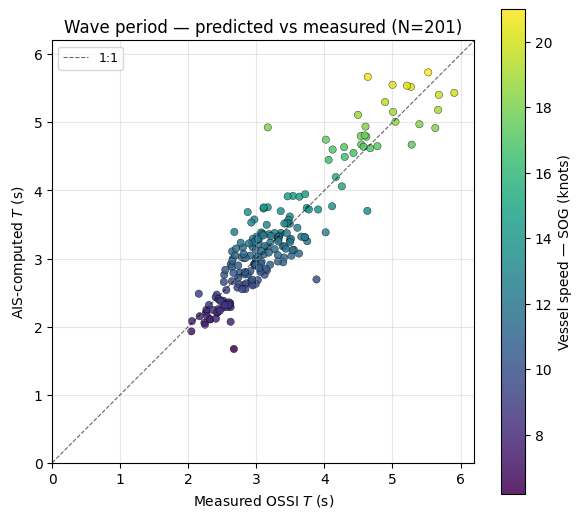

In [20]:
# === Cell 9h-period: QQ plot of AIS-computed wave period vs OSSI measured period ===
# Uses events["WavePeriod"] (from compute_point_impact) and events["T_measured"]
# (from Cell 9e). Point colour encodes vessel speed (SOG, knots).
valid_T = events[["WavePeriod", "T_measured", "SOG"]].dropna()
valid_T = valid_T[(valid_T["WavePeriod"] > 0) & (valid_T["T_measured"] > 0)]

fig, ax = plt.subplots(figsize=(6, 6))

if valid_T.empty:
    ax.text(0.5, 0.5, "No matched period data", ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")
else:
    meas = valid_T["T_measured"].to_numpy()
    pred = valid_T["WavePeriod"].to_numpy()
    sog  = valid_T["SOG"].to_numpy()

    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=float(sog.min()), vmax=float(sog.max()))

    sc = ax.scatter(meas, pred, c=sog, cmap=cmap, norm=norm,
                    s=28, alpha=0.85, edgecolor="k", lw=0.3)

    lim = max(meas.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.6, label="1:1")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Measured OSSI $T$ (s)")
    ax.set_ylabel("AIS-computed $T$ (s)")
    ax.set_title(f"Wave period — predicted vs measured (N={len(valid_T)})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Vessel speed — SOG (knots)")

fig.tight_layout()
fig.savefig(out / "qq_period.png", dpi=150, bbox_inches="tight")
print(f"  saved qq_period.png")
plt.show()

In [21]:
# === Cell 9i: OSSI comparison — Step 9 ===
# Summary statistics for matched events
if n_matched > 0:
    stats_rows = []
    for label, col in pred_cols.items():
        valid = events[["Hmax_measured", col]].dropna()
        if valid.empty:
            continue
        meas = valid["Hmax_measured"].to_numpy()
        pred = valid[col].to_numpy()
        bias = np.mean(pred - meas)
        rmse = np.sqrt(np.mean((pred - meas) ** 2))
        r2 = np.corrcoef(meas, pred)[0, 1] ** 2 if len(meas) > 1 else float("nan")
        stats_rows.append({"Formula": label, "N": len(meas),
                           "Bias (m)": f"{bias:.4f}", "RMSE (m)": f"{rmse:.4f}",
                           "R²": f"{r2:.3f}"})
    df_stats = pd.DataFrame(stats_rows)
    print("\nSummary statistics (matched events):")
    display(df_stats)

    # Save matched events CSV
    matched_cols = ["DateTime", "ArrivalTime", "MMSI", "PropDist_m", "DistPerp_m",
                    "SOG", "VesselLength", "VesselWidth", "Side", "segment_id",
                    "Hmax_measured"] + list(pred_cols.values())
    out_cols = [c for c in matched_cols if c in events.columns]
    events[out_cols][events["Hmax_measured"].notna()].to_csv(out / "matched_events.csv", index=False)
    print(f"  saved matched_events.csv")
else:
    print("No matched events — try widening event_window or checking time alignment.")


Summary statistics (matched events):


,Formula,N,Bias (m),RMSE (m),R²
0,Kriebel,105,0.0572,0.1883,0.170
1,PIANC,196,0.2019,0.4879,0.016
2,Sorensen,201,1.2016,1.3099,0.196
3,Maynord,146,1.5600,1.8595,0.000
4,Bhowmik,201,0.3375,0.3664,0.065
5,Gates,173,1.1647,1.3969,0.146
6,Blaauw,196,0.5757,0.8150,0.044


  saved matched_events.csv



OLS  Y' = log(g2*H*Le^(2/3)*y^(1/3)/V^4) - 1.5  ~  Fr_Le

subset             N             β0        β·Fr_Le   d_avg   L/Le      R2   adjR2       cond
--------------------------------------------------------------------------------------------
  All            201        -0.1678         1.0172    0.45   2.49   0.920   0.919        2.4
  Fr_d<1.5       165        -0.2198         0.8509    0.48   2.31   0.766   0.764        1.9
  Fr_d>=1.5       36         0.2256         1.1861    0.31   3.31   0.677   0.667       26.6
  c0              48        -0.1060         1.0582    0.39   1.81   0.606   0.598        7.5
  c1              50         0.0305         1.0028    0.55   2.67   0.856   0.853        2.2
  c2              27        -0.5566         1.0837    0.49   3.21   0.737   0.726        2.9
  c3              21        -0.5988         0.5845    0.41   1.64   0.490   0.463        7.0
  c4              25        -0.1022         0.9370    0.53   2.81   0.622   0.606        1.9
  c5       

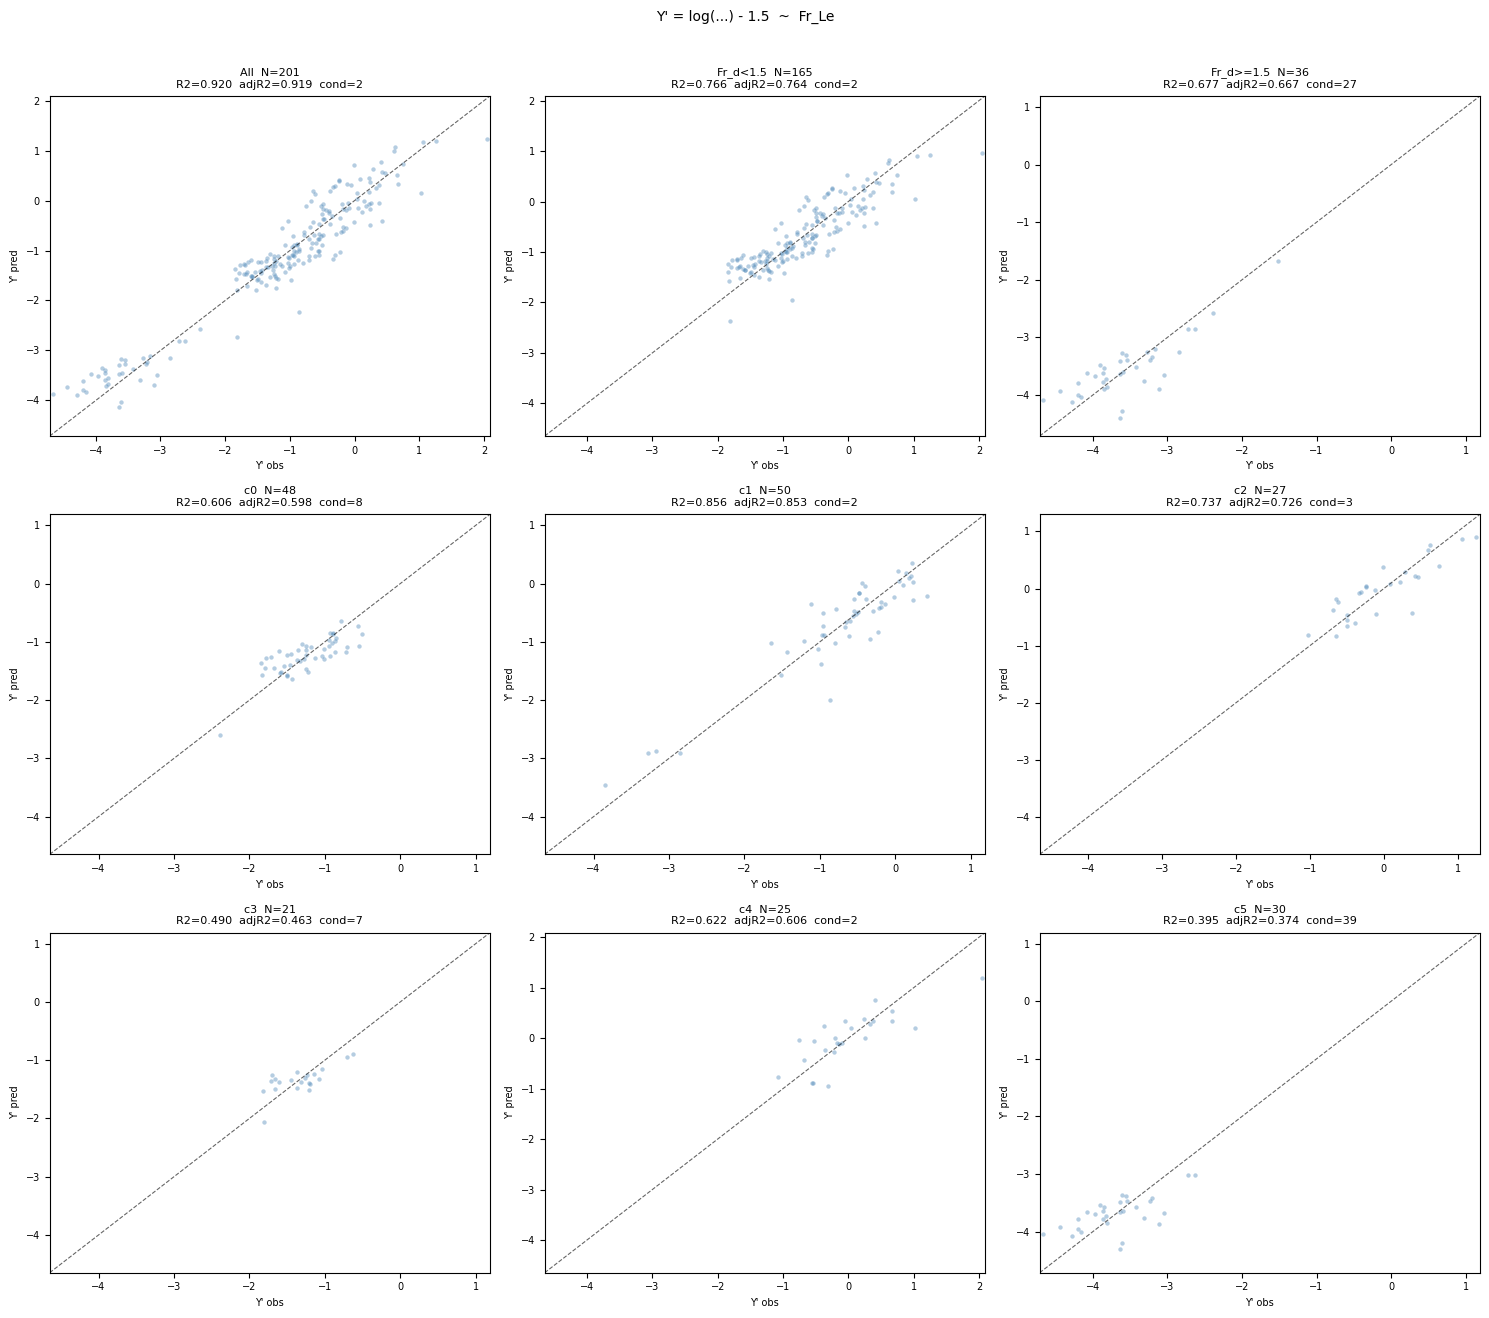

saved data\compare_JI\output\comparison\regression_9j.png


In [80]:
# Cell 9j — OLS regression on dimensionless wake height
# Clusters reused from Cell 9h-kriebel (_kriebel_cluster_map).
import numpy as np
import matplotlib.pyplot as plt

# ── build working frame & raw arrays ──────────────────────────────────────────
_g  = gravity
_em = events.copy()
_req = ["SOGms", "draught", "WaterDepth", "dist_perp",
        "length", "width", "bow_entry_m", "block_coeff", "MMSI"]
_em = _em.dropna(subset=_req)
_em = _em[(_em["SOGms"]      > 0) & (_em["dist_perp"]  > 0) &
           (_em["WaterDepth"] > 0) & (_em["bow_entry_m"] > 0) &
           (_em["length"]     > 0) & (_em["width"]       > 0)]
if "Hmax_measured" not in _em.columns:
    _em = _em.merge(events[["MMSI", "Hmax_measured"]].drop_duplicates(),
                    on="MMSI", how="left")
_em = _em.dropna(subset=["Hmax_measured"])
_em = _em[_em["Hmax_measured"] > 0].reset_index(drop=True)

_V  = _em["SOGms"].values
_L  = _em["length"].values
_B  = _em["width"].values
_Le = _em["bow_entry_m"].values
_d  = _em["draught"].values
_h  = _em["WaterDepth"].values
_y  = _em["dist_perp"].values
_Cb = _em["block_coeff"].values
_H  = _em["Hmax_measured"].values

_Y = np.log(_g**2 * _H * _Le**(2/3) * _y**(1/3) / _V**4)   # target

# ╔══ EDIT HERE — define up to 6 regression variables ══════════════════════════╗
# Each entry: ("col_name",  "display label",  numpy_expression)
# Available arrays (all same length, aligned to _em rows):
#   _V (m/s)  _L (m)  _B (m)  _Le (m)  _d (m)  _h (m)  _y (m)  _Cb  _g (scalar)
#
_VARS = [
    ("Fr_Le",     "Fr_Le",         2.5 * (1 - 1.5 * np.power(_V / np.sqrt(_g * _Le), 0.5))* np.sqrt(_L * _Le) / _B),
    #("Fr_Le",     "Fr_Le",         np.power(_V / np.sqrt(_g * _Le), 0.5)),
    #("Fr_B",      "Fr_B",         _V / np.sqrt(_g * _B)* (_d)**0.1),
    #("sqrtLLe_B", "sqrt(L*Le)/B", np.sqrt(_L * _Le) / _B),
    #("Fr_d",  "Fr_d",  _V / np.sqrt(_g * _d) * (_d)**0.25),
    #("L_d",  "L/d",  _L / _d),
    # ── further candidates (uncomment to add, max 6 total) ─────────────────
    #("Fr_L",      "Fr_L",         _V / np.sqrt(_g * _L) * (_d / _L)**-0.3),
    # ("Fr_Le",     "Fr_Le",        _V / np.sqrt(_g * _Le)),
    # ("sqrtLLe_B", "sqrt(L*Le)/B", np.sqrt(_L * _Le) / _B),
    # ("Fr_h",      "Fr_h",         _V / np.sqrt(_g * _h)),
    # ("Fr_B",      "Fr_B",         _V / np.sqrt(_g * _B)),
    # ("L_Le",      "L/Le",         _L / _Le),
    # ("B_Le",      "B/Le",         _B / _Le),
    # ("d_h",       "d/h",          _d / _h),
    # ("Cb",        "Cb",           _Cb),
    # ("Frd2",      "Fr_d^2",       (_V / np.sqrt(_g * _d))**2),
]
# ╚═════════════════════════════════════════════════════════════════════════════╝

assert 1 <= len(_VARS) <= 6, f"Define 1-6 variables, got {len(_VARS)}"
_FEAT_COLS  = [v[0] for v in _VARS]
_FEAT_LABEL = [v[1] for v in _VARS]

# ── assemble regression frame (retains all _em columns for clean indexing) ─────
_rdf = _em.copy()
_rdf["_Y"]    = _Y
_rdf["_Fr_d"] = _V / np.sqrt(_g * _d)   # subset splitting only
for _col, _lbl, _arr in _VARS:
    _rdf[_col] = _arr

# ── cluster labels from Cell 9h-kriebel ───────────────────────────────────────
if "_kriebel_cluster_map" not in dir():
    raise RuntimeError("Run Cell 9h-kriebel first to populate _kriebel_cluster_map")
_rdf["cluster"] = _rdf["MMSI"].map(_kriebel_cluster_map)
_rdf = _rdf.dropna(subset=["cluster"]).reset_index(drop=True)
_rdf["cluster"] = _rdf["cluster"].astype(int)

# ── OLS helper ────────────────────────────────────────────────────────────────
def _ols(y, X):
    n, p = X.shape
    D = np.column_stack([np.ones(n), X])
    coef, _, _, _ = np.linalg.lstsq(D, y, rcond=None)
    yh     = D @ coef
    ss_res = np.sum((y - yh)**2)
    ss_tot = np.sum((y - y.mean())**2)
    R2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    df     = n - p - 1
    adjR2  = 1 - (1 - R2) * (n - 1) / df if df > 0 else np.nan
    cond   = np.linalg.cond(D)
    return coef, R2, adjR2, np.sqrt(ss_res / df) if df > 0 else np.nan, cond

# ── subsets ───────────────────────────────────────────────────────────────────
_Fr_d_arr = _rdf["_Fr_d"].values
_cl_arr   = _rdf["cluster"].values
_n_clust  = int(_cl_arr.max()) + 1

_subsets = (
    [("All",       np.ones(len(_rdf), bool)),
     ("Fr_d<1.5",  _Fr_d_arr < 1.5),
     ("Fr_d>=1.5", _Fr_d_arr >= 1.5)]
    + [(f"c{k}", _cl_arr == k) for k in range(_n_clust)]
)

# ── regressions ───────────────────────────────────────────────────────────────
_Xmat  = _rdf[_FEAT_COLS].values
_Y_arr = _rdf["_Y"].values
_min_n = len(_FEAT_COLS) + 2

_results = []
for _name, _mask in _subsets:
    _N = _mask.sum()
    if _N < _min_n:
        _results.append({"name": _name, "N": _N, "ok": False})
        continue
    _coef, _R2, _aR2, _s, _cond = _ols(_Y_arr[_mask], _Xmat[_mask])
    _results.append({
        "name": _name, "N": _N, "ok": True,
        "b0": _coef[0],
        **{f"b_{c}": _coef[i+1] for i, c in enumerate(_FEAT_COLS)},
        "R2": _R2, "adjR2": _aR2, "s": _s, "cond": _cond,
        "d_avg":   (np.sqrt(_rdf["bow_entry_m"].values[_mask] / _rdf["width"].values[_mask])  * np.sqrt(_rdf["draught"].values[_mask] / _rdf["width"].values[_mask])).mean(),
        #"LLe_avg": (_rdf["length"].values[_mask] / _rdf["bow_entry_m"].values[_mask]).mean(),
        "LLe_avg": (np.sqrt(_rdf["bow_entry_m"].values[_mask] / _rdf["draught"].values[_mask])  * np.sqrt(_rdf["width"].values[_mask] / _rdf["draught"].values[_mask])).mean(),
    })

# ── console table ─────────────────────────────────────────────────────────────
_W = 13
_beta_labels = ["β0"] + [f"β·{lb}" for lb in _FEAT_LABEL]
_hdr = (f"{'subset':<14} {'N':>5}"
        + "".join(f"  {lb:>{_W}}" for lb in _beta_labels)
        + f"  {'d_avg':>6}  {'L/Le':>5}  {'R2':>6}  {'adjR2':>6}  {'cond':>9}")
print(f"\nOLS  Y' = log(g2*H*Le^(2/3)*y^(1/3)/V^4) - 1.5  ~  {' + '.join(_FEAT_LABEL)}\n")
print(_hdr)
print("-" * len(_hdr))
for _r in _results:
    if not _r["ok"]:
        print(f"  {_r['name']:<12} {_r['N']:>5}  (too few - need >{_min_n-1})")
        continue
    _vals = [_r["b0"]] + [_r[f"b_{c}"] for c in _FEAT_COLS]
    print(f"  {_r['name']:<12} {_r['N']:>5}"
          + "".join(f"  {v:>{_W}.4f}" for v in _vals)
          + f"  {_r['d_avg']:>6.2f}  {_r['LLe_avg']:>5.2f}"
          + f"  {_r['R2']:>6.3f}  {_r['adjR2']:>6.3f}  {_r['cond']:>9.1f}")

# ── 3x3 pred-vs-obs figure ────────────────────────────────────────────────────
_fig, _axes = plt.subplots(3, 3, figsize=(15, 13))
_Ylo, _Yhi = np.percentile(_Y_arr, [2, 98])
_mg = (_Yhi - _Ylo) * 0.08

for _idx, (_r, (_, _mask)) in enumerate(zip(_results, _subsets)):
    _ax = _axes.flat[_idx]
    if not _r["ok"]:
        _ax.text(0.5, 0.5, "(no fit)", ha="center", va="center",
                 transform=_ax.transAxes, fontsize=9)
        continue
    _ym   = _Y_arr[_mask]
    _Yhat = (np.column_stack([np.ones(_mask.sum()), _Xmat[_mask]])
             @ np.array([_r["b0"]] + [_r[f"b_{c}"] for c in _FEAT_COLS]))
    _lo = min(_Ylo - _mg, _ym.min(), _Yhat.min()) - 0.05
    _hi = max(_Yhi + _mg, _ym.max(), _Yhat.max()) + 0.05
    _ax.scatter(_ym, _Yhat, s=10, alpha=0.4, color="steelblue", linewidths=0)
    _ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=0.8, alpha=0.6)
    _ax.set_xlim(_lo, _hi); _ax.set_ylim(_lo, _hi)
    _ax.set_title(f"{_r['name']}  N={_r['N']}\n"
                  f"R2={_r['R2']:.3f}  adjR2={_r['adjR2']:.3f}  cond={_r['cond']:.0f}",
                  fontsize=8)
    _ax.set_xlabel("Y' obs", fontsize=7)
    _ax.set_ylabel("Y' pred", fontsize=7)
    _ax.tick_params(labelsize=7)

_fig.suptitle("Y' = log(...) - 1.5  ~  " + " + ".join(_FEAT_LABEL), fontsize=10, y=1.01)
_fig.tight_layout()
_out_png = out / "regression_9j.png"
_fig.savefig(_out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {_out_png}")



=== All  (N=201  R2=0.072  adjR2=0.067  F=15.4  RMSE=0.3725  cond=3.3) ===
  rank  variable             β          SE     t-stat    p-value   sig
  ----  ----------  ----------  ----------  ---------  ---------  ----
     —  intercept      -1.9842      0.0470    -42.188     0.0000   ***
     1  log(V)          0.1807      0.0460      3.931     0.0001   ***

=== Fr_d<1.5  (N=165  R2=0.160  adjR2=0.155  F=31.1  RMSE=0.3719  cond=3.7) ===
  rank  variable             β          SE     t-stat    p-value   sig
  ----  ----------  ----------  ----------  ---------  ---------  ----
     —  intercept      -2.1081      0.0559    -37.723     0.0000   ***
     1  log(V)          0.4157      0.0746      5.573     0.0000   ***

=== Fr_d>=1.5  (N=36  R2=0.079  adjR2=0.052  F=2.9  RMSE=0.2662  cond=20.0) ===
  rank  variable             β          SE     t-stat    p-value   sig
  ----  ----------  ----------  ----------  ---------  ---------  ----
     —  intercept      -1.1213      0.3881     -2.88

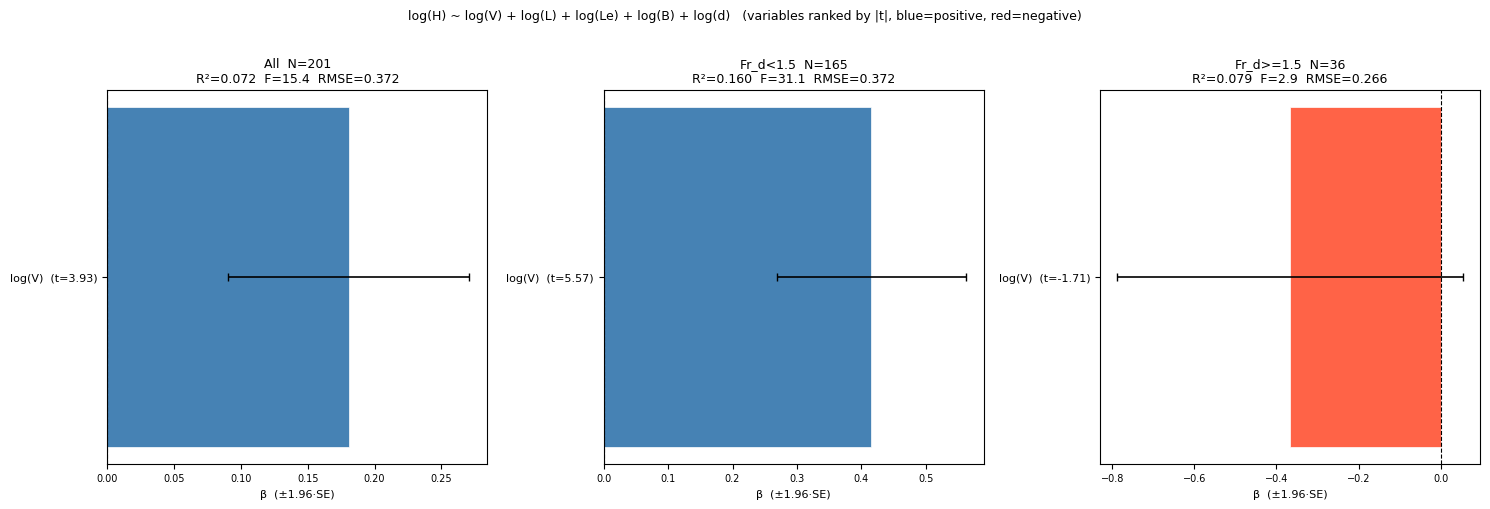

saved data\compare_JI\output\comparison\regression_logH.png


In [69]:
# Cell 9k — log-log OLS: log(H) ~ log(V) + log(L) + log(Le) + log(B) + log(d)
# Subsets: All | Fr_d < 1.5 | Fr_d >= 1.5  (no k-means clusters)
# Reports SE, t-stat, p-value per coefficient; ranks variables by |t|.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as _tdist

# ── working frame & arrays ─────────────────────────────────────────────────────
_g2  = gravity
_em2 = events.copy()
_req2 = ["SOGms", "draught", "length", "width", "bow_entry_m",
         "WaterDepth", "dist_perp", "MMSI"]
_em2 = _em2.dropna(subset=_req2)
_em2 = _em2[(_em2["SOGms"]      > 0) & (_em2["length"]     > 0) &
             (_em2["bow_entry_m"] > 0) & (_em2["width"]      > 0) &
             (_em2["draught"]    > 0)].copy()
if "Hmax_measured" not in _em2.columns:
    _em2 = _em2.merge(events[["MMSI", "Hmax_measured"]].drop_duplicates(),
                      on="MMSI", how="left")
_em2 = _em2.dropna(subset=["Hmax_measured"])
_em2 = _em2[_em2["Hmax_measured"] > 0].reset_index(drop=True)

_V2  = _em2["SOGms"].values
_L2  = _em2["length"].values
_B2  = _em2["width"].values
_Le2 = _em2["bow_entry_m"].values
_d2  = _em2["draught"].values
_H2  = _em2["Hmax_measured"].values

_logH  = np.log(_H2)
_Fr_d2 = _V2 / np.sqrt(_g2 * _d2)

FEAT_COLS  = ["logV",    "logL",    "logLe",    "logB",    "logd"]
FEAT_LABEL = ["log(V)", "log(L)", "log(Le)", "log(B)", "log(d)"]

_Xmat2 = np.column_stack([
    np.log(_V2/np.sqrt(_Le2)),
])

_subsets2 = [
    ("All",       np.ones(len(_em2), bool)),
    ("Fr_d<1.5",  _Fr_d2 < 1.5),
    ("Fr_d>=1.5", _Fr_d2 >= 1.5),
]

# ── OLS with full inference ────────────────────────────────────────────────────
def _ols_inf(y, X):
    n, p = X.shape
    D  = np.column_stack([np.ones(n), X])
    coef, _, _, _ = np.linalg.lstsq(D, y, rcond=None)
    yh     = D @ coef
    ss_res = np.sum((y - yh)**2)
    ss_tot = np.sum((y - y.mean())**2)
    ss_reg = ss_tot - ss_res
    df_res = n - p - 1
    R2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    adjR2  = 1 - (1 - R2) * (n - 1) / df_res if df_res > 0 else np.nan
    s2     = ss_res / df_res if df_res > 0 else np.nan
    F      = (ss_reg / p) / s2 if (s2 and s2 > 0) else np.nan
    SE     = np.sqrt(np.maximum(np.diag(np.linalg.pinv(D.T @ D)) * s2, 0))
    t_stat = coef / np.where(SE > 0, SE, np.nan)
    p_val  = 2 * _tdist.sf(np.abs(t_stat), df=df_res)
    cond   = np.linalg.cond(D)
    rmse   = np.sqrt(ss_res / n)
    return coef, SE, t_stat, p_val, R2, adjR2, F, cond, rmse

# ── fit all subsets & console output ──────────────────────────────────────────
_fits = []
for _name, _mask in _subsets2:
    _N = _mask.sum()
    if _N < len(FEAT_COLS) + 2:
        print(f"\n=== {_name}  (N={_N} — too few) ===")
        _fits.append(None)
        continue

    _coef, _SE, _t, _p, _R2, _aR2, _F, _cond, _rmse = _ols_inf(
        _logH[_mask], _Xmat2[_mask]
    )
    _fits.append((_coef, _SE, _t, _p, _R2, _aR2, _F, _cond, _rmse, _N, _mask))

    # rank features (exclude intercept) by |t|
    _feat_order = np.argsort(-np.abs(_t[1:]))   # descending |t|

    print(f"\n=== {_name}  (N={_N}  R2={_R2:.3f}  adjR2={_aR2:.3f}"
          f"  F={_F:.1f}  RMSE={_rmse:.4f}  cond={_cond:.1f}) ===")
    print(f"  {'rank':>4}  {'variable':<10}  {'β':>10}  {'SE':>10}"
          f"  {'t-stat':>9}  {'p-value':>9}  {'sig':>4}")
    print(f"  {'':->4}  {'':->10}  {'':->10}  {'':->10}"
          f"  {'':->9}  {'':->9}  {'':->4}")
    # intercept first
    _sig0 = "***" if _p[0] < 0.001 else ("**" if _p[0] < 0.01 else
             ("*" if _p[0] < 0.05 else ""))
    print(f"  {'—':>4}  {'intercept':<10}  {_coef[0]:>10.4f}  {_SE[0]:>10.4f}"
          f"  {_t[0]:>9.3f}  {_p[0]:>9.4f}  {_sig0:>4}")
    for _rank, _fi in enumerate(_feat_order, 1):
        _sig = "***" if _p[_fi+1] < 0.001 else ("**" if _p[_fi+1] < 0.01 else
               ("*" if _p[_fi+1] < 0.05 else ""))
        print(f"  {_rank:>4}  {FEAT_LABEL[_fi]:<10}  {_coef[_fi+1]:>10.4f}"
              f"  {_SE[_fi+1]:>10.4f}  {_t[_fi+1]:>9.3f}"
              f"  {_p[_fi+1]:>9.4f}  {_sig:>4}")

# ── figure: 3 panels — ranked coefficient plots ────────────────────────────────
_fig2, _axes2 = plt.subplots(1, 3, figsize=(15, 5))
_colors = {"pos": "steelblue", "neg": "tomato"}

for _ax, _fit, (_name, _mask) in zip(_axes2, _fits, _subsets2):
    if _fit is None:
        _ax.set_title(f"{_name}\n(no fit)", fontsize=9)
        continue

    _coef, _SE, _t, _p, _R2, _aR2, _F, _cond, _rmse, _N, _ = _fit
    _feat_order = np.argsort(-np.abs(_t[1:]))   # descending |t|, features only

    _betas = _coef[1:][_feat_order]
    _ses   = _SE[1:][_feat_order]
    _ts    = _t[1:][_feat_order]
    _labs  = [FEAT_LABEL[i] for i in _feat_order]
    _cols  = [_colors["pos"] if b >= 0 else _colors["neg"] for b in _betas]
    _y_pos = np.arange(len(_betas))

    _ax.barh(_y_pos, _betas, xerr=1.96 * _ses,
             color=_cols, edgecolor="white", linewidth=0.5,
             error_kw={"elinewidth": 1.2, "ecolor": "black", "capsize": 3})
    _ax.axvline(0, color="black", lw=0.8, ls="--")
    _ax.set_yticks(_y_pos)
    _ax.set_yticklabels([f"{lb}  (t={_ts[i]:.2f})" for i, lb in enumerate(_labs)],
                        fontsize=8)
    _ax.set_xlabel("β  (±1.96·SE)", fontsize=8)
    _ax.set_title(f"{_name}  N={_N}\nR²={_R2:.3f}  F={_F:.1f}  RMSE={_rmse:.3f}",
                  fontsize=9)
    _ax.tick_params(axis="x", labelsize=7)
    _ax.invert_yaxis()   # rank 1 at top

_fig2.suptitle("log(H) ~ " + " + ".join(FEAT_LABEL)
               + "   (variables ranked by |t|, blue=positive, red=negative)",
               fontsize=9, y=1.01)
_fig2.tight_layout()
_out_png2 = out / "regression_logH.png"
_fig2.savefig(_out_png2, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {_out_png2}")
